# **SPECTRA testing notebook**

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import argparse
import yaml
import pickle
import torch
import networkx as nx
import scanpy as sc
import numpy as np
import pandas as pd
import warnings
import os
import anndata as ad

ad.settings.allow_write_nullable_strings = True

# Suppress annoying warnings for a clean console
warnings.filterwarnings("ignore")

In [3]:
# torch device setting
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(torch.version.cuda)
    print(torch.cuda.get_device_name())
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

12.1
Tesla V100-SXM2-32GB
Using device: cuda


In [4]:
from spectra.utils import set_seed
from spectra.data import data_preprocessing, build_model_dataloaders_perts_split, compute_weights
from spectra.model import SPECTRA

### **Load config file**

In [9]:
config_path = '../configs/vcc_config_3layers.yaml'

with open(config_path, 'r') as file:
    config = yaml.safe_load(file)
print(yaml.dump(config, indent=2, sort_keys=False, default_flow_style=False))

project:
  name: SPECTRA_vcc_FINAL
  seed: 42
  deterministic: false
  use_wandb: true
data:
  adata_path: /scratch/michele.calabro/gears/VCC/SPECTRA/data/adata_vcc.h5ad
  gene_list_path: /scratch/michele.calabro/gears/VCC/SPECTRA/data/gene_list-vcc.txt
  network_path: /scratch/michele.calabro/gears/VCC/SPECTRA/data/vcc_4/VCC_4_chitin.tsv
  scgpt_embeddings_path: /scratch/michele.calabro/gears/VCC/SPECTRA/data/scGPT_embeddings_all_genes.pkl
  gene_weights_path: /scratch/michele.calabro/gears/VCC/SPECTRA/data/gene_weights-vcc.pkl
model:
  architecture: vcc_final
  conv_type: FAGCN
  residual_weight: 0.3589162920376502
  n_channels: 48
  dropout_p: 0.3746613855008784
  num_node_features: 1
training:
  batch_size: 16
  lr: 0.001
  n_epochs: 20
  alpha: 1.8
  beta: 0.01
  gamma: 2.6
  eta: 3.3
  test_ratio: 0.2
  val_ratio: 0.1



In [6]:
# Initialization & Seeding - set it to deterministic for reproducibility
set_seed(seed=config['project']['seed'], deterministic=config['project']['deterministic'])

### **Load files**

In [7]:
# Load adata
adata = sc.read_h5ad(config['data']['adata_path'])
adata = data_preprocessing(adata,
    logtransform=True, 
    min_cells_per_pert=100) # or 50
adata

View of AnnData object with n_obs × n_vars = 220998 × 18020
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

In [8]:
# scGPT gene embeddings
with open(config['data']['scgpt_embeddings_path'], "rb") as f:
    scgpt_dict = pickle.load(f)

In [9]:
# load GRN
network_data = pd.read_csv(config['data']['network_path'], sep='\t')
G = nx.DiGraph()
for _, edge in network_data.iterrows():
    G.add_edge(edge['source'], edge['target'], weight=edge['weight'])

G.remove_nodes_from([n for n in G.nodes if n not in scgpt_dict])
grn_genes = set(G.nodes)

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)

Number of nodes: 4922
Number of edges: 151764


In [ ]:
# save list of nodes
with open("mysetgenes.txt", "w",) as f:
    for item in grn_genes:
        f.write(f"{item}\n")

In [10]:
# Filter adata to match final network genes
gene_list = grn_genes & set(adata.var_names)
if grn_genes != gene_list:
    print('WARNING: some genes in the provided gene list are not included in the grn, or the gene embeddings are missing; filtering them out...')
adata = adata[:, adata.var_names.isin(gene_list)]

In [11]:
# Filter out perturbations that aren't in the gene list
perturbations = list(adata.obs['target_gene'].unique())
perturbations.remove('non-targeting')
perts_not_included = list({
    pert for pert in perturbations
    if any(single_pert not in gene_list for single_pert in pert.split('+'))
})
if len(perts_not_included)>0:
    print(print('WARNING: some perturbed genes are not included in the GRN. Filtering these perturbation samples out...'))
adata = adata[~adata.obs['target_gene'].isin(perts_not_included)].copy()

### **Edge indices, embeddings matrix**
Other preparation steps fro SPECTRA

In [12]:
# shuffle data, sanity check
adata = adata[np.random.permutation(adata.n_obs), :]
assert set(G.nodes) == set(adata.var_names), "Nodes in G and adata.var_names differ!"

In [13]:
# Map Edge Index
gene_to_idx = {node: i for i, node in enumerate(adata.var_names)}
edges = [(gene_to_idx[u], gene_to_idx[v]) for u, v in G.edges()]
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

In [14]:
# Build embedding matrix
scgpt_dict = {gene_to_idx[k]: v for k, v in scgpt_dict.items() if k in gene_to_idx}
scgpt_dim = len(next(iter(scgpt_dict.values())))
embedding_matrix = torch.zeros((num_nodes, scgpt_dim))
for gene_id, emb in scgpt_dict.items():
    embedding_matrix[gene_id] = torch.tensor(emb, dtype=torch.float32)

In [13]:
adata.write('../results/adata_processed_ready2train.h5ad')

### **Dataloaders creation**

In [15]:
perturbations = list(adata.obs['target_gene'].unique())
perturbations.remove('non-targeting')

# Merge config dictionaries for the model/dataloaders
model_config = {**config['model'], **config['training']}
model_config['dataset_size'] = adata.shape[0]
model_config['pert_to_idx'] = {pert: i for i, pert in enumerate(perturbations)}

In [16]:
from spectra.data import build_model_dataloaders_from_perts_list

train_loader, val_loader, test_loader, _, _, _, train_adata, _, test_adata = build_model_dataloaders_from_perts_list(adata, model_config, '/scratch/michele.calabro/gears/VCC/SPECTRA/data/vcc_4/VCC_4_split_indices.json')

Total Unique Perturbations: 148
Train set: 108 perts | 138271 cells
Val set: 20 perts | 25375 cells
Test set: 20 perts | 19176 cells


In [17]:
# Load WMSE Weights
weights_path = config['data']['gene_weights_path']
if os.path.exists(weights_path):
    print('found already existing gene weights dictionary! Loading...')
    with open(weights_path, 'rb') as f:
        gene_weights = pickle.load(f)
else:
    print('No gene weights dictionary found. Calculating...')
    gene_weights = compute_weights(train_adata, gene_to_idx, cells_per_pert=256)
    with open(weights_path, 'wb') as f:
        pickle.dump(gene_weights, f)

found already existing gene weights dictionary! Loading...


### **Model initialization**

In [18]:
model = SPECTRA(
    edge_index=edge_index, 
    num_nodes=num_nodes, 
    device=device, 
    config=model_config,
    gene_embeddings=embedding_matrix,
    gene_weights=gene_weights
).to(device)
print(model)

number of trainable parameters: 76481
SPECTRA(
  (gene_embeddings): Embedding(4922, 512)
  (project_gene): Linear(in_features=512, out_features=64, bias=True)
  (film_layer): GeneExpressionFiLM(
    (scale): Linear(in_features=1, out_features=64, bias=True)
    (shift): Linear(in_features=1, out_features=64, bias=True)
  )
  (add_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (ko_mlp): MLP(
    (network): Sequential(
      (0): Dropout(p=0.0, inplace=False)
      (1): Linear(in_features=512, out_features=64, bias=True)
      (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (encoder): VariationalGraphEncoder(
    (conv1): DirFAGCNConv(64)
    (conv2): DirFAGCNConv(64)
    (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (proj_mu): Linear(in_features=64, out_features=64, bias=True)
    (proj_logstd): Linear(in_features=64, out_features=64, bias=Tru

### **Testing**

In [39]:
# best_model_FUNGI_FAGCN_vcc_final_demntfs7 requires 3 layers
model.load_state_dict(torch.load("../weights/best_model_vcc_WMMDonly_li06qg95.pth")) 

<All keys matched successfully>

In [40]:
model.eval()

SPECTRA(
  (gene_embeddings): Embedding(4922, 512)
  (project_gene): Linear(in_features=512, out_features=64, bias=True)
  (film_layer): GeneExpressionFiLM(
    (scale): Linear(in_features=1, out_features=64, bias=True)
    (shift): Linear(in_features=1, out_features=64, bias=True)
  )
  (add_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (ko_mlp): MLP(
    (network): Sequential(
      (0): Dropout(p=0.0, inplace=False)
      (1): Linear(in_features=512, out_features=64, bias=True)
      (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (encoder): VariationalGraphEncoder(
    (conv1): DirFAGCNConv(64)
    (conv2): DirFAGCNConv(64)
    (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (proj_mu): Linear(in_features=64, out_features=64, bias=True)
    (proj_logstd): Linear(in_features=64, out_features=64, bias=True)
  )
  (gex_decoder): FeatureDecoder

In [21]:
# for perturbation split
n_min_samples = 30
counts = test_adata.obs['target_gene'].value_counts()
counts = counts[counts >= n_min_samples]

# creation of dict: for each pertuyrbation how many cells to generate
gene_counts_dict = counts.drop('non-targeting').to_dict() 

real_adata = test_adata[test_adata.obs['target_gene'].isin(counts.index)]
real_adata

View of AnnData object with n_obs × n_vars = 24336 × 4922
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'

In [46]:
control_adata = real_adata[real_adata.obs['target_gene']=='non-targeting']

In [47]:
from spectra.model import generate_from_control

pred_adata = generate_from_control(gene_counts_dict, control_adata, model, gene_to_idx, add_control=True)
pred_adata

100%|██████████| 20/20 [01:50<00:00,  5.55s/it]


AnnData object with n_obs × n_vars = 24336 × 4922
    obs: 'target_gene'

In [27]:
###########################################################################################
############################ generate n_runs SPECTRA outputs ##############################
###########################################################################################
from tqdm import tqdm
from spectra.model import generate_from_control

N_RUNS = 10
OUTPUT_DIR = '/scratch/michele.calabro/gears/VCC/SPECTRA/results/final_vcc'
for i in tqdm(range(N_RUNS)):
    pred_adata = generate_from_control(gene_counts_dict, control_adata, model, gene_to_idx, add_control=False)
    pred_adata.write(f'{OUTPUT_DIR}/pred_adata-SPECTRA-{i}.h5ad')

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [18:58<00:00, 113.87s/it]


In [28]:
from spectra.evaluation import generate_adata_baseline

pred_adata_2 = generate_adata_baseline(gene_counts_dict, train_adata) #adata[:train_size,:]

# Append the non-targeting controls to the example anndata if they're missing - needed for DEGs overlap metrics
ntc_adata = real_adata[real_adata.obs["target_gene"] == "non-targeting"]
if "non-targeting" not in pred_adata_2.obs["target_gene"].unique():
    assert np.all(pred_adata_2.var_names.values == ntc_adata.var_names.values), (
        "Gene-Names are out of order or unequal"
    )
    pred_adata_2 = ad.concat(
        [
            pred_adata_2,
            ntc_adata,
        ]
    )
del ntc_adata
pred_adata_2

100%|██████████| 20/20 [00:00<00:00, 185.33it/s]


AnnData object with n_obs × n_vars = 24336 × 4922
    obs: 'target_gene'

In [33]:
with open('../results/final_vcc/vcc_gene_counts_dict.pkl', 'wb') as f:
    pickle.dump(gene_counts_dict, f)

In [28]:
###########################################################################################
############################ generate n_runs baseline outputs #############################
###########################################################################################
from tqdm import tqdm
from spectra.evaluation import generate_adata_baseline

N_RUNS = 10
OUTPUT_DIR = '/scratch/michele.calabro/gears/VCC/SPECTRA/results/final_vcc'
for i in tqdm(range(N_RUNS)):
    pred_adata = generate_adata_baseline(gene_counts_dict, train_adata)
    pred_adata.write(f'{OUTPUT_DIR}/pred_adata-baseline-{i}.h5ad')

100%|██████████| 10/10 [00:39<00:00,  3.91s/it]


In [71]:
# gears model
adata_gears = sc.read_h5ad('/scratch/michele.calabro/gears/VCC/SPECTRA/temp/data/pred_adata.h5ad')
adata_gears.obs.rename(columns={'condition': 'target_gene'}, inplace=True)
adata_gears.obs["target_gene"] = adata_gears.obs["target_gene"].str.replace(r"\+ctrl$", "", regex=True)
adata_gears.X = np.clip(adata_gears.X, a_min=0, a_max=None)
adata_gears = ad.concat([adata_gears, control_adata], axis=0)
adata_gears

AnnData object with n_obs × n_vars = 21834 × 4914
    obs: 'target_gene'

In [48]:
# real_adata.write('../results/final_vcc/real_adata_vcc.h5ad')
pred_adata.write('../results/final_vcc/pred_adata-SPECTRA_WMMD.h5ad')
# pred_adata_2.write('../results/final_vcc/pred_adata-baseline.h5ad')
# adata_gears.write('../results/pred_adata-GEARS.h5ad')

In [49]:
!python ../scripts/evaluate.py \
    --real ../results/final_vcc/real_adata_vcc.h5ad \
    --pred ../results/final_vcc/pred_adata-SPECTRA_WMMD.h5ad \
      ../results/final_vcc/pred_adata-baseline.h5ad \
    --metrics auprc f1\
    --top_DEGs 50

[*] Loading real dataset from: ../results/final_vcc/real_adata_vcc.h5ad
[*] Loading prediction for model 'SPECTRA_WMMD': pred_adata-SPECTRA_WMMD.h5ad
    -> Calculating auprc...
100%|███████████████████████████████████████████| 20/20 [01:58<00:00,  5.91s/it]

--- Summary ---
Average Baseline AUPRC: 0.0773
Average Model AUPRC:    0.0916
    -> Calculating f1...
100%|███████████████████████████████████████████| 20/20 [00:53<00:00,  2.67s/it]
[*] Loading prediction for model 'baseline': pred_adata-baseline.h5ad
    -> Calculating auprc...
100%|███████████████████████████████████████████| 20/20 [01:53<00:00,  5.65s/it]

--- Summary ---
Average Baseline AUPRC: 0.0773
Average Model AUPRC:    0.0881
    -> Calculating f1...
100%|███████████████████████████████████████████| 20/20 [00:51<00:00,  2.57s/it]
[*] All evaluations complete.


In [36]:
from spectra.evaluation import *

Average mae: 0.0396
Average correlation: 0.9914


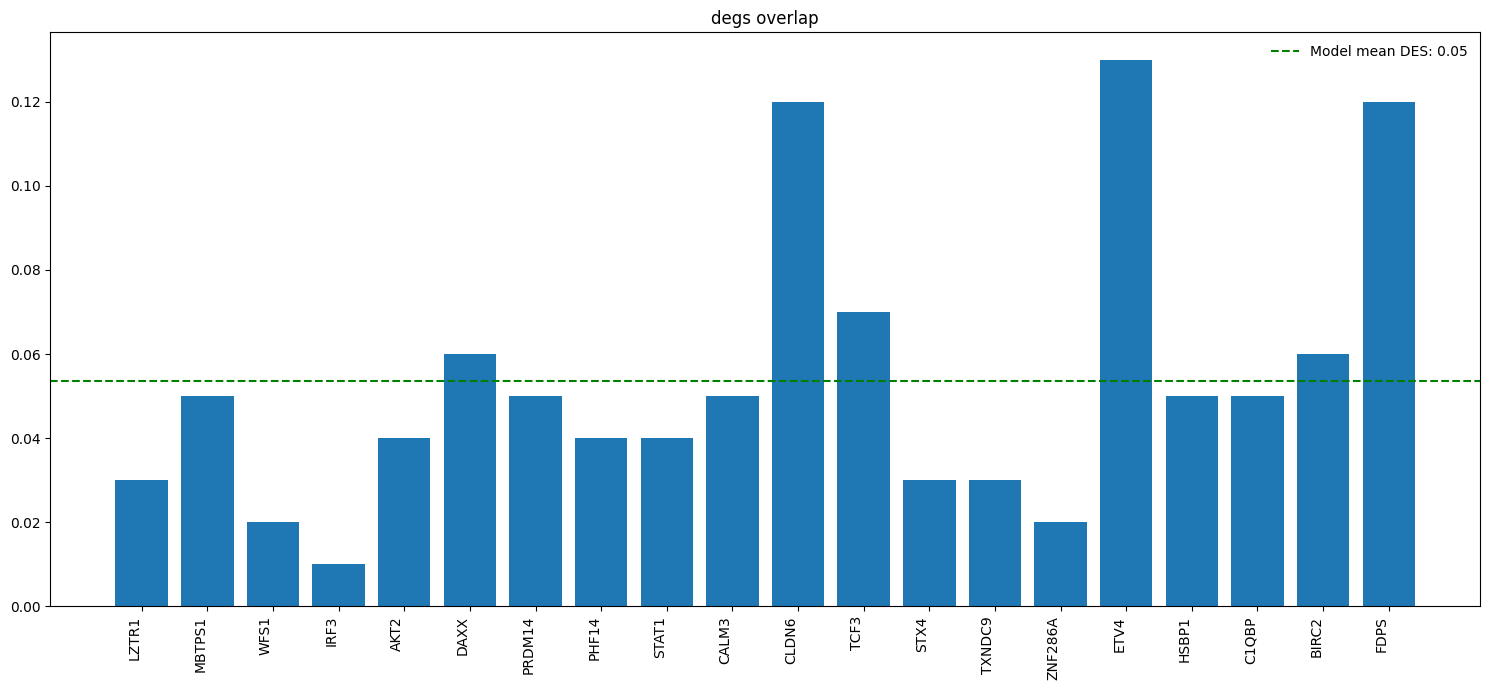

In [39]:

score_mae = calc_mae(real_adata, pred_adata)
print(f"Average mae: {sum(score_mae.values())/len(score_mae):.4f}")

score_corr = calc_corr(real_adata, pred_adata)
print(f"Average correlation: {sum(score_corr.values())/len(score_corr):.4f}")

model_results = calc_common_degs(real_adata, pred_adata)
eval_barplot(model_results, 'degs overlap')

### Other analysis

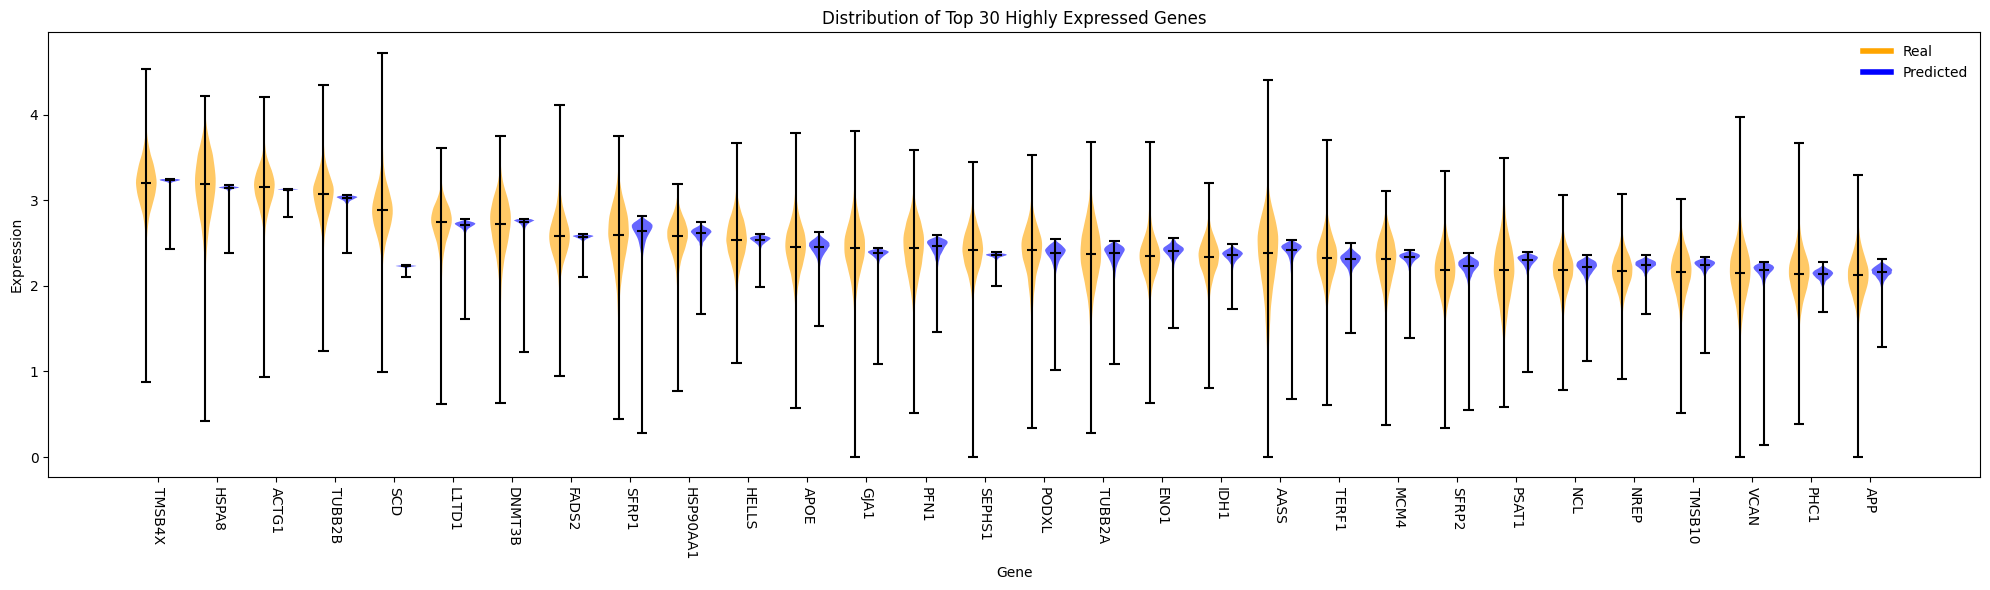

In [41]:
plot_top_highly_expressed_genes(30, real_adata[real_adata.obs['target_gene']!='non-targeting'], pred_adata[pred_adata.obs['target_gene']!='non-targeting'], False)

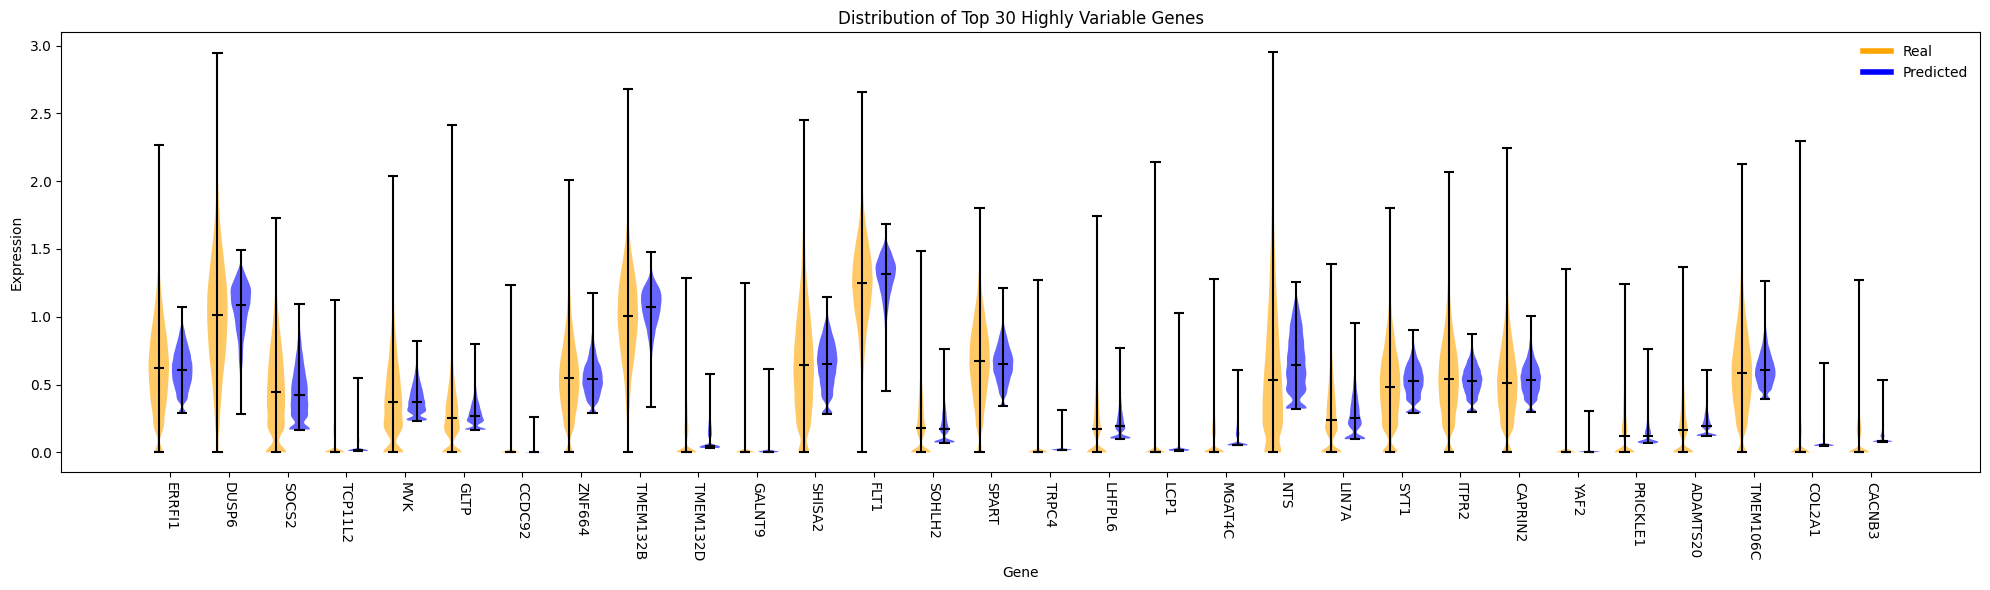

In [40]:
plot_top_highly_variable_genes(30, real_adata[real_adata.obs['target_gene']!='non-targeting'], pred_adata[pred_adata.obs['target_gene']!='non-targeting'], False)

In [32]:
pred_adata.obs['target_gene'].unique()

['PRCP', 'TADA1', 'TSC22D4', 'FOXH1', 'KLF10', ..., 'PMEL', 'KIF20A', 'SALL4', 'FDPS', 'non-targeting']
Length: 23
Categories (23, object): ['CDCA2', 'FDPS', 'FOXH1', 'HAT1', ..., 'XRCC4', 'ZNF426', 'ZNF562', 'non-targeting']

**let's try with just the DE genes**

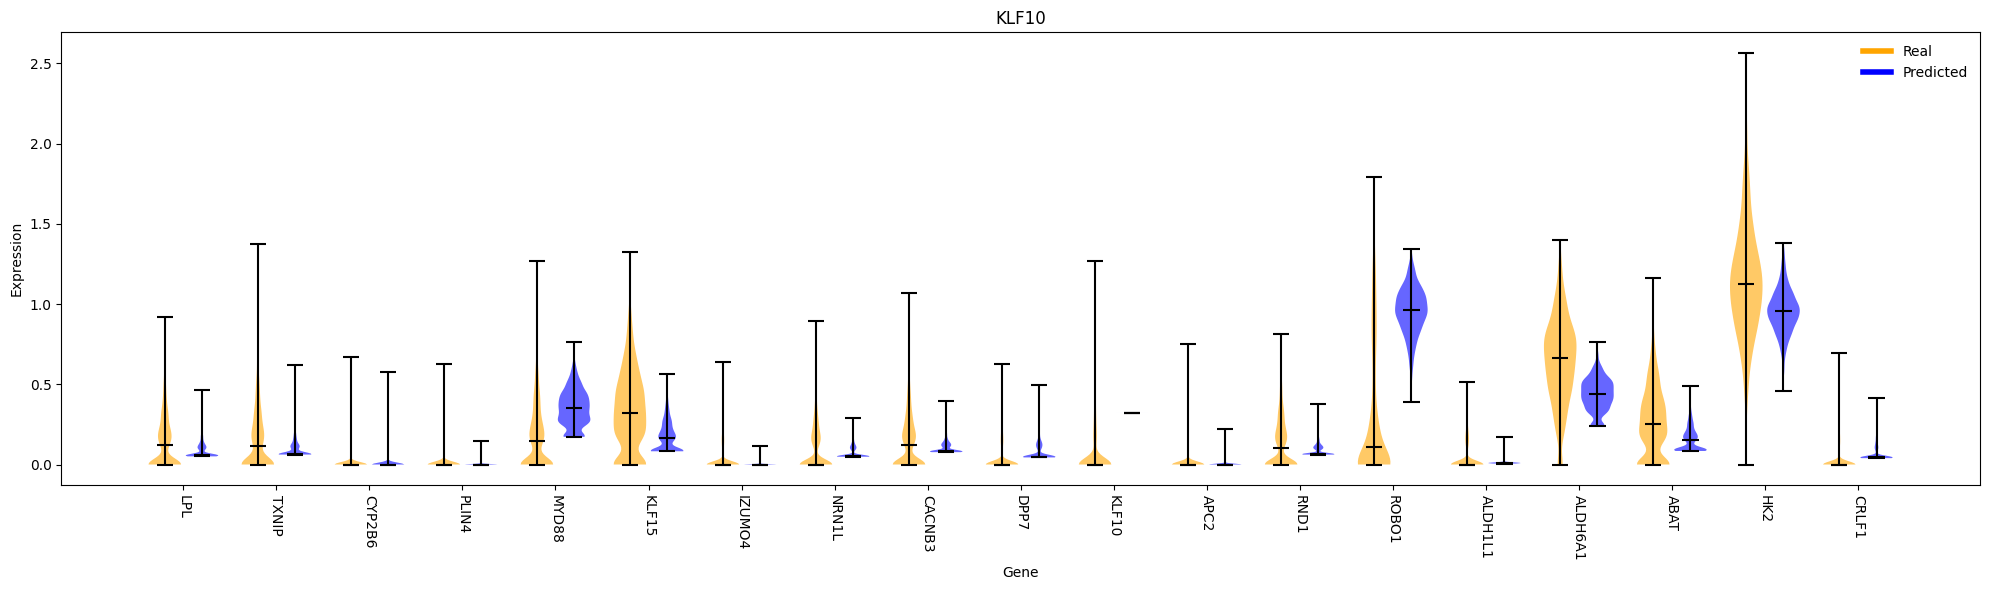

In [37]:
des_calculator = RobustDES(lfc_threshold=0.5, alpha=0.05)

max_de_genes = 20
perturb_label = 'KLF10'
DE_genes, _ = des_calculator.get_de_genes(real_adata, 'target_gene', perturb_label, 'non-targeting')
list_DE_genes = list(set(DE_genes.index))
if len(list_DE_genes)>max_de_genes:
    list_DE_genes = list(set(DE_genes.loc[DE_genes['logfoldchanges'].abs().sort_values(ascending=False).index[:max_de_genes]].index))

plot_violins_predictions_selected_genes(list_DE_genes, 
    real_adata[real_adata.obs['target_gene']==perturb_label], 
    pred_adata[pred_adata.obs['target_gene']==perturb_label], 
    False, 
    perturb_label
)

### **Attention network analysis**

In [21]:
# Assuming you have loaded your trained model weights...
model.eval()

# Grab a single batch (e.g., TP53 knockouts) - NOTE: this is just an example
x,y,pert,pert_idx = next(iter(test_loader)) 

# Get the attention matrices
A_Agg, _, _ = model((x,pert), return_attention_weights=True)

# perturbation 
pert = pert[0]
index = torch.nonzero(pert).squeeze().numpy()
idx_to_gene = {idx:gene for gene, idx in gene_to_idx.items()}
perturbed_gene = idx_to_gene[index.item()]
print(perturbed_gene)
print('============')

# Shows where information originates from Node $i$ and travels to other nodes 
shockwaves={idx_to_gene[i]:A_Agg[index, i] for i in range(A_Agg.shape[0])}

# Inspect the shockwave - Sort keys by descending absolute value, take top 10
top_10_keys = sorted(shockwaves, 
                    key=lambda k: abs(shockwaves[k]), 
                    reverse=True)[:10]
top_10_dict = {k: shockwaves[k].item() for k in top_10_keys}
print(top_10_dict)

# building networkx digraph from adjacency matrix
attention_graph = nx.from_numpy_array(A_Agg.cpu().detach().numpy(), create_using=nx.DiGraph)
attention_graph = nx.relabel_nodes(attention_graph, idx_to_gene)
print(attention_graph.number_of_nodes())
print(attention_graph.number_of_edges())

PMS1
{'PLEKHN1': 0.0, 'ISG15': 0.0, 'AGRN': 0.0, 'ACAP3': 0.0, 'MXRA8': 0.0, 'CCNL2': 0.0, 'VWA1': 0.0, 'TMEM240': 0.0, 'MMP23B': 0.0, 'PRKCZ': 0.0}
4914
4323363


In [43]:
target_gene = "PRDM14"  # Change this to any perturbation you want to analyze

if target_gene not in gene_to_idx:
    raise ValueError(f"Gene '{target_gene}' not found in gene mapping.")
target_idx = gene_to_idx[target_gene]
idx_to_gene = {idx: gene for gene, idx in gene_to_idx.items()}

# ---------------------------------------------------------
# 2. FIND THE BATCH
# ---------------------------------------------------------
target_batch = None

# Iterate through the loader to find the specific perturbation
for x, y, pert, pert_idx in test_loader:
    # pert is shape [B, N]. Check if the target_idx is active (1.0)
    # Since batches contain unique perturbations, checking the first item is sufficient
    if pert[0, target_idx] > 0:
        target_batch = (x, y, pert, pert_idx)
        break

if target_batch is None:
    raise ValueError(f"Batch for perturbation '{target_gene}' not found in test_loader.")

x, y, pert, pert_idx = target_batch
x = x.to(model.device)
y = y.to(model.device)
pert = pert.to(model.device)

with torch.no_grad():
    A_Agg, _, _ = model((x, pert), return_attention_weights=True)

# perturbation 
pert = pert[0]
index = torch.nonzero(pert).squeeze().cpu().numpy()
idx_to_gene = {idx:gene for gene, idx in gene_to_idx.items()}
perturbed_gene = idx_to_gene[index.item()]
print(perturbed_gene)
print('============')

# Shows where information originates from Node $i$ and travels to other nodes 
shockwaves={idx_to_gene[i]:A_Agg[index, i] for i in range(A_Agg.shape[0])}

# Inspect the shockwave - Sort keys by descending absolute value, take top 10
top_10_keys = sorted(shockwaves, 
                    key=lambda k: abs(shockwaves[k]), 
                    reverse=True)[:10]
top_10_dict = {k: shockwaves[k].item() for k in top_10_keys}
print(top_10_dict)

# building networkx digraph from adjacency matrix
attention_graph = nx.from_numpy_array(A_Agg.cpu().detach().numpy(), create_using=nx.DiGraph)
attention_graph = nx.relabel_nodes(attention_graph, idx_to_gene)
print(attention_graph.number_of_nodes())
print(attention_graph.number_of_edges())

PRDM14
{'SHROOM3': -144.0431365966797, 'EHD3': -119.85809326171875, 'NDRG1': -115.91751098632812, 'CYP2C8': -108.95059204101562, 'NR5A1': -105.6991195678711, 'LTBP1': -100.89456176757812, 'TRPV6': -100.88563537597656, 'FAM102B': -98.00518798828125, 'TM4SF1': -97.61615753173828, 'CCDC121': -97.50143432617188}
4914
17133322


Total non-zero edges: 169075
Max attention weight: 1.000000
Min attention weight: -0.194254
Median attention weight: 0.018868
95th percentile: 0.055556


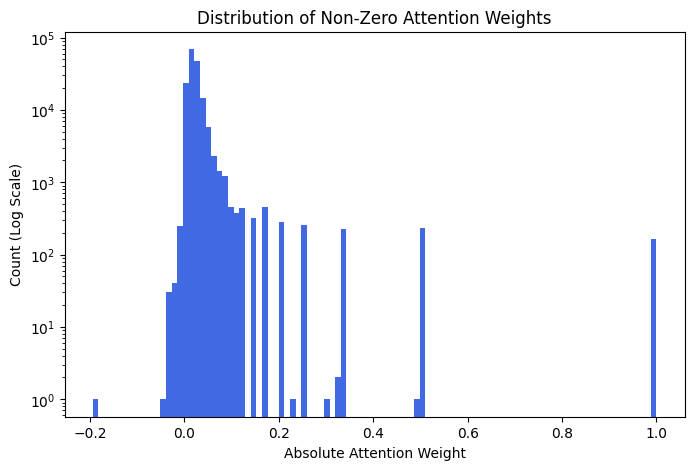

In [36]:
import matplotlib.pyplot as plt
import numpy as np

A_dense = A_1hop.cpu().detach().numpy()
# Flatten and get absolute values of only the non-zero edges
non_zero_weights = A_dense[A_dense != 0.]

print(f"Total non-zero edges: {len(non_zero_weights)}")
print(f"Max attention weight: {non_zero_weights.max():.6f}")
print(f"Min attention weight: {non_zero_weights.min():.6f}")
print(f"Median attention weight: {np.median(non_zero_weights):.6f}")
print(f"95th percentile: {np.percentile(non_zero_weights, 95):.6f}")

plt.figure(figsize=(8, 5))
# Using a log scale because usually 99% of weights are microscopic
plt.hist(non_zero_weights, bins=100, color='royalblue', log=True)
plt.title("Distribution of Non-Zero Attention Weights")
plt.xlabel("Absolute Attention Weight")
plt.ylabel("Count (Log Scale)")
plt.show()

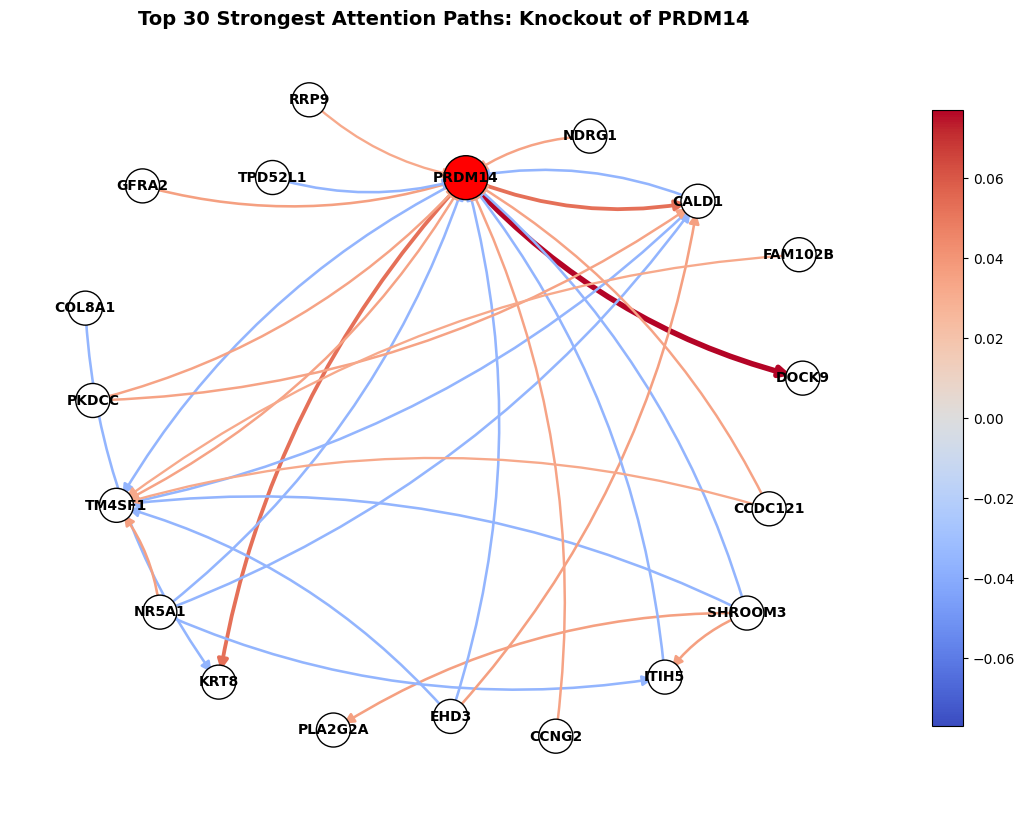

In [37]:
# Global noise floor (keeps graph building fast)
minimum_signal = 1e-6
A_dense[np.abs(A_dense) < minimum_signal] = 0.0

attention_graph = nx.from_numpy_array(A_dense, create_using=nx.DiGraph)
attention_graph = nx.relabel_nodes(attention_graph, idx_to_gene)

# NOTE: rimotion of self-loops
attention_graph.remove_edges_from(nx.selfloop_edges(attention_graph))


# Extract Ego-Graph
try:
    subgraph = nx.ego_graph(attention_graph, perturbed_gene, radius=1, center=True)
except nx.NodeNotFound:
    print(f"Node {perturbed_gene} has no edges above the noise floor.")
    subgraph = nx.DiGraph()

if len(subgraph.nodes) > 1:
    K_edges = 30
    
    # 3. STORE BOTH SIGNED AND ABSOLUTE WEIGHTS
    edges_with_weights = [
        (u, v, data['weight'], abs(data['weight'])) 
        for u, v, data in subgraph.edges(data=True)
    ]
    
    # Sort strictly by the ABSOLUTE magnitude to find the strongest signals
    edges_with_weights.sort(key=lambda x: x[3], reverse=True)
    top_edges = edges_with_weights[:K_edges]
    
    clean_subgraph = nx.DiGraph()
    for u, v, w, abs_w in top_edges:
        clean_subgraph.add_edge(u, v, weight=w, abs_weight=abs_w)
    
    # 4. Visualization Setup
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(clean_subgraph, k=0.8, seed=42)
    
    # Highlight perturbed node in bold RED, targets in muted GRAY
    node_colors = ["#ffb100" if node == perturbed_gene else "white" for node in clean_subgraph.nodes()]
    node_sizes = [1000 if node == perturbed_gene else 600 for node in clean_subgraph.nodes()]
    
    nx.draw_networkx_nodes(clean_subgraph, pos, node_color=node_colors, node_size=node_sizes, edgecolors='black')
    nx.draw_networkx_labels(clean_subgraph, pos, font_size=10, font_weight="bold")
    
    # 5. DYNAMIC EDGE STYLING
    signed_weights = [w for _, _, w, _ in top_edges]
    abs_weights = [abs_w for _, _, _, abs_w in top_edges]
    max_abs_w = max(abs_weights) if abs_weights else 1.0
    edge_widths = [(abs_w / max_abs_w) * 4. for abs_w in abs_weights]
    
    # Create a symmetric color scale centered exactly at 0
    vmin = -max_abs_w
    vmax = max_abs_w
    cmap = plt.cm.coolwarm
    
    edge_draw = nx.draw_networkx_edges(
        clean_subgraph, pos, 
        width=edge_widths, 
        edge_color=signed_weights, 
        edge_cmap=cmap,
        edge_vmin=vmin,    # Locks the bottom of the colormap to the negative max
        edge_vmax=vmax,    # Locks the top of the colormap to the positive max
        arrowsize=15, 
        connectionstyle='arc3,rad=0.15' # Increased curve to separate bidirectional arrows
    )
    
    # Add Colorbar matched to the diverging scale
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.8)
    #cbar.set_label("Attention Flow (Blue = Negative, Red = Positive)", fontsize=12)
    
    plt.title(f"Top {K_edges} Strongest Attention Paths: Knockout of {perturbed_gene}", fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.show()
else:
    print("Not enough local downstream nodes found.")

In [ ]:
# Global noise floor (keeps graph building fast)
minimum_signal = 1e-1
A_dense[np.abs(A_dense) < minimum_signal] = 0.0

attention_graph = nx.from_numpy_array(A_dense, create_using=nx.DiGraph)
attention_graph = nx.relabel_nodes(attention_graph, idx_to_gene)

# NOTE: rimotion of self-loops
attention_graph.remove_edges_from(nx.selfloop_edges(attention_graph))


# Extract Ego-Graph
try:
    subgraph = nx.ego_graph(attention_graph, perturbed_gene, radius=1, center=True)
except nx.NodeNotFound:
    print(f"Node {perturbed_gene} has no edges above the noise floor.")
    subgraph = nx.DiGraph()

if len(subgraph.nodes) > 1:
    K_total = 30
    K_direct_minimum = 15 # Guarantee at least 15 edges touch the perturbed gene
    
    direct_edges = []
    indirect_edges = []
    
    # Separate edges into those touching the ego node, and those that don't
    for u, v, data in subgraph.edges(data=True):
        edge_tuple = (u, v, data['weight'], abs(data['weight']))
        if u == perturbed_gene or v == perturbed_gene:
            direct_edges.append(edge_tuple)
        else:
            indirect_edges.append(edge_tuple)
            
    # Sort both pools by absolute magnitude
    direct_edges.sort(key=lambda x: x[3], reverse=True)
    indirect_edges.sort(key=lambda x: x[3], reverse=True)
    
    # Secure the protected direct edges
    selected_direct = direct_edges[:K_direct_minimum]
    
    # Throw the leftover direct edges back into the general pool
    remaining_pool = direct_edges[K_direct_minimum:] + indirect_edges
    remaining_pool.sort(key=lambda x: x[3], reverse=True)
    
    # Fill the rest of the quota with the strongest remaining edges
    remaining_quota = K_total - len(selected_direct)
    selected_indirect = remaining_pool[:remaining_quota]
    
    # Combine to form our final Top K list
    top_edges = selected_direct + selected_indirect
    
    clean_subgraph = nx.DiGraph()
    for u, v, w, abs_w in top_edges:
        clean_subgraph.add_edge(u, v, weight=w, abs_weight=abs_w)
    
    # 4. Visualization Setup
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(clean_subgraph, k=0.8, seed=42)
    
    # Highlight perturbed node in bold RED, targets in muted GRAY
    node_colors = ["red" if node == perturbed_gene else "white" for node in clean_subgraph.nodes()]
    node_sizes = [1000 if node == perturbed_gene else 600 for node in clean_subgraph.nodes()]
    
    nx.draw_networkx_nodes(clean_subgraph, pos, node_color=node_colors, node_size=node_sizes, edgecolors='black')
    
    label_pos = {}
    shift_amount = 0.05 # Adjust this number if the labels are too far or too close
    for node, (x, y) in pos.items():
        label_pos[node] = (x, y - shift_amount)
    nx.draw_networkx_labels(clean_subgraph, label_pos, font_size=9, font_weight="bold")
    
    # 5. DYNAMIC EDGE STYLING
    signed_weights = [w for _, _, w, _ in top_edges]
    abs_weights = [abs_w for _, _, _, abs_w in top_edges]
    max_abs_w = max(abs_weights) if abs_weights else 1.0
    edge_widths = [(abs_w / max_abs_w) * 4. for abs_w in abs_weights]
    
    # Create a symmetric color scale centered exactly at 0
    vmin = -max_abs_w
    vmax = max_abs_w
    cmap = plt.cm.coolwarm
    
    edge_draw = nx.draw_networkx_edges(
        clean_subgraph, pos, 
        width=edge_widths, 
        edge_color=signed_weights, 
        edge_cmap=cmap,
        edge_vmin=vmin,    # Locks the bottom of the colormap to the negative max
        edge_vmax=vmax,    # Locks the top of the colormap to the positive max
        arrowsize=15, 
        connectionstyle='arc3,rad=0.15' # Increased curve to separate bidirectional arrows
    )
    
    # Add Colorbar matched to the diverging scale
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.8)
    #cbar.set_label("Attention Flow (Blue = Negative, Red = Positive)", fontsize=12)
    
    plt.title(f"Top {K_edges} Strongest Attention Paths: Knockout of {perturbed_gene}", fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.show()
else:
    print("Not enough local downstream nodes found.")

***
### **Subgraphs**

In [23]:
list_interesting_perturbations = [
    'POU5F1',
    'SOX2',
    'NANOG',
    'TDGF1',
    'SMAD2/3',
    'FGFR1',
    'DNMT3B',
    'TP53',
    'BMP4',
    'CTNNB1',
    'PRDM14',
    'LIN28A',
    'OCT4'
]

In [24]:
intersection = list(set(real_adata.obs['target_gene'].unique().tolist()) & set(list_interesting_perturbations))
print(intersection)

['PRDM14']


In [35]:
def downstream_A_from_alpha(edge_index, alpha, N, edge_weight=None):
    """
    Builds A[src, dst] for original directed edges src -> dst.
    This is row-source / column-target convention.
    """
    src, dst = edge_index
    deg_in = torch.bincount(dst, minlength=N).float().clamp_min(1.0).to(alpha.device)
    vals = alpha / deg_in[dst]

    if edge_weight is not None:
        vals = vals * edge_weight.to(alpha.device)

    A = torch.sparse_coo_tensor(
        torch.stack([src, dst]),
        vals,
        (N, N),
        device=alpha.device
    ).to_dense()

    return A

@torch.no_grad()
def compute_downstream_path_matrices(model, x, pert):
    model.eval()

    y_hat, x_hat, (a1, a2, a3) = model(
        (x, pert),
        return_attention_weights=True
    )

    B = pert.shape[0]
    N = model.num_nodes
    E = model.edge_index.shape[1]

    alpha1 = a1["alpha_in"].view(B, E)
    alpha2 = a2["alpha_in"].view(B, E)
    alpha3 = a3["alpha_in"].view(B, E)

    A1_sum = torch.zeros(N, N, device=model.device)
    A12_sum = torch.zeros(N, N, device=model.device)
    A123_sum = torch.zeros(N, N, device=model.device)

    for b in range(B):
        A1 = downstream_A_from_alpha(model.edge_index, alpha1[b], N)
        A2 = downstream_A_from_alpha(model.edge_index, alpha2[b], N)
        A3 = downstream_A_from_alpha(model.edge_index, alpha3[b], N)

        A12 = A1 @ A2
        A123 = A12 @ A3

        A1_sum += A1
        A12_sum += A12
        A123_sum += A123

    return {
        "one_hop": A1_sum / B,
        "two_hops": A12_sum / B,
        "three_hops": A123_sum / B
    }, y_hat, x_hat

top edges limit:

In [36]:
from matplotlib import pyplot as plt
from tqdm import tqdm

minimum_signal = 1e-4
K_edges = 30
model.eval()

# perturbation to analyze
target_gene = "PRDM14" 
if target_gene not in gene_to_idx:
    raise ValueError(f"Gene '{target_gene}' not found in gene mapping.")
target_idx = gene_to_idx[target_gene]

# Iterate batches through the loader to find the specific perturbation
for x, y, pert, pert_idx in test_loader:
    if pert_idx[0].item() == model_config['pert_to_idx'][target_gene]:
        target_batch = (x, y, pert, pert_idx)
        break

if target_batch is None:
    raise ValueError(f"Batch for perturbation '{target_gene}' not found in test_loader.")

x, y, pert, pert_idx = target_batch
x = x.to(model.device)
y = y.to(model.device)
pert = pert.to(model.device)
idx_to_gene = {idx:gene for gene, idx in gene_to_idx.items()}


# attention graphs
A_Agg, _, _ = compute_downstream_path_matrices(model, x, pert)

3it [01:23, 27.93s/it]


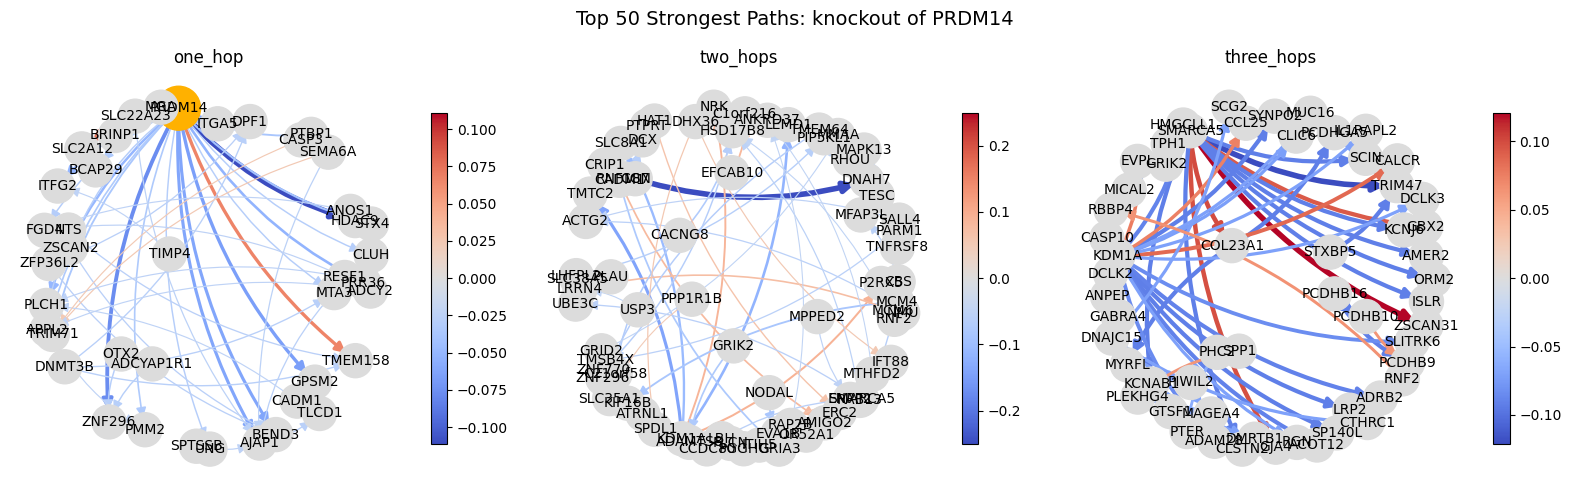

In [35]:
idx_to_gene = {idx:gene for gene, idx in gene_to_idx.items()}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Top {K_edges} Strongest Paths: knockout of {target_gene}', fontsize=14)
cmap = plt.cm.coolwarm

for i, current_hop in tqdm(enumerate(A_Agg.keys())):

    A = A_Agg[current_hop]
    A_dense = A.cpu().detach().numpy()
    A_dense[np.abs(A_dense) < minimum_signal] = 0.0

    # building networkx digraph from adjacency matrix
    attention_graph = nx.from_numpy_array(A_dense, create_using=nx.DiGraph)
    attention_graph = nx.relabel_nodes(attention_graph, idx_to_gene)

    # NOTE: rimotion of self-loops
    attention_graph.remove_edges_from(nx.selfloop_edges(attention_graph))

    # Extract Ego-Graph of. target gene
    try:
        subgraph = nx.ego_graph(attention_graph, target_gene, radius=1, center=True)
    except nx.NodeNotFound:
        print(f"Node {perturbed_gene} has no edges above the noise floor.")
        subgraph = nx.DiGraph()


    if len(subgraph.nodes) > 1:
        
        # store signed and absolute weights
        edges_with_weights = [
            (u, v, data['weight'], abs(data['weight'])) 
            for u, v, data in subgraph.edges(data=True)
        ]
        
        # Sort strictly by the absolute magnitude to find the strongest signals
        edges_with_weights.sort(key=lambda x: x[3], reverse=True)
        top_edges = edges_with_weights[:K_edges]
        
        clean_subgraph = nx.DiGraph()
        for u, v, w, abs_w in top_edges:
            clean_subgraph.add_edge(u, v, weight=w, abs_weight=abs_w)
        
        # Visualization Setup
        pos = nx.spring_layout(clean_subgraph, k=0.2, iterations=60, seed=42)
        node_colors = ["#ffb100" if node == target_gene else "gainsboro" for node in clean_subgraph.nodes()]
        node_sizes = [1000 if node == target_gene else 600 for node in clean_subgraph.nodes()]
        nx.draw_networkx_nodes(clean_subgraph, pos, ax=axes[i], node_color=node_colors, node_size=node_sizes, edgecolors=None)
        nx.draw_networkx_labels(clean_subgraph, pos, ax=axes[i], font_size=10)
        
        # dynamic edge syling
        signed_weights = [w for _, _, w, _ in top_edges]
        abs_weights = [abs_w for _, _, _, abs_w in top_edges]
        max_abs_w = max(abs_weights) if abs_weights else 1.0
        edge_widths = [(abs_w / max_abs_w) * 4. for abs_w in abs_weights]
        vmin = -max_abs_w
        vmax = max_abs_w
        
        edge_draw = nx.draw_networkx_edges(
            clean_subgraph, pos, 
            ax=axes[i],
            width=edge_widths, 
            edge_color=signed_weights, 
            edge_cmap=cmap,
            edge_vmin=vmin,    # Locks the bottom of the colormap to the negative max
            edge_vmax=vmax,    # Locks the top of the colormap to the positive max
            arrowsize=15, 
            connectionstyle='arc3,rad=0.15' # Increased curve to separate bidirectional arrows
        )
        
        # Add Colorbar matched to the diverging scale
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
        sm.set_array([])
        #cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.8)
        fig.colorbar(sm, ax=axes[i], shrink=0.8)
        axes[i].set_title(f"{current_hop}")
        #cbar.set_label("Attention Flow (Blue = Negative, Red = Positive)", fontsize=12)
        
        axes[i].set_axis_off()
    else:
        print("Not enough local downstream nodes found.")

plt.tight_layout()
plt.show()


max nodes limit (not necessarily shared across subplots):

one_hop
4922
151721
two_hops
4922
3597564
three_hops
4922
6298071


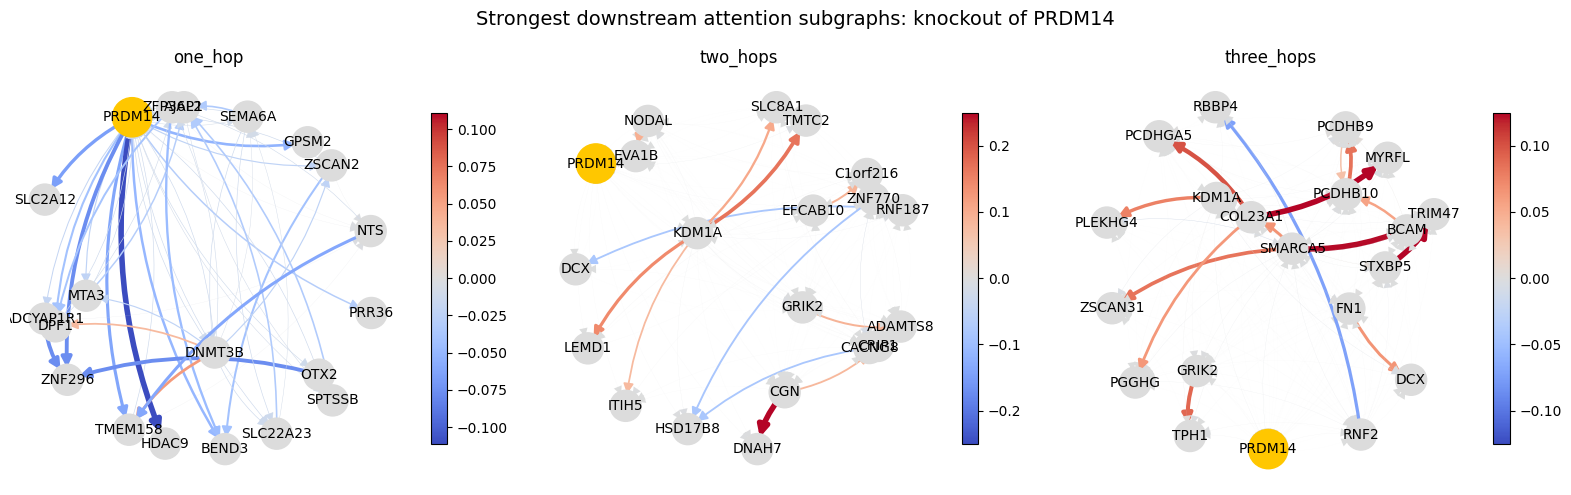

In [41]:
minimum_signal = 1e-4
MAX_NODES = 20

target_gene = "PRDM14"
target_batch = None

if target_gene not in gene_to_idx:
    raise ValueError(f"Gene '{target_gene}' not found in gene mapping.")

target_idx = gene_to_idx[target_gene]

for x, y, pert, pert_idx in test_loader:
    if pert_idx[0].item() == model_config["pert_to_idx"][target_gene]:
        target_batch = (x, y, pert, pert_idx)
        break

if target_batch is None:
    raise ValueError(f"Batch for perturbation '{target_gene}' not found in test_loader.")

x, y, pert, pert_idx = target_batch
x = x.to(model.device)
y = y.to(model.device)
pert = pert.to(model.device)

model.eval()

A_Agg, _, _ = compute_downstream_path_matrices(model, x, pert)

idx_to_gene = {idx: gene for gene, idx in gene_to_idx.items()}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f"Strongest downstream attention subgraphs: knockout of {target_gene}",
    fontsize=14
)

cmap = plt.cm.coolwarm

for i, current_hop in enumerate(A_Agg.keys()):

    A = A_Agg[current_hop]
    A_dense = A.cpu().detach().numpy()
    A_dense[np.abs(A_dense) < minimum_signal] = 0.0

    attention_graph = nx.from_numpy_array(A_dense, create_using=nx.DiGraph)
    attention_graph = nx.relabel_nodes(attention_graph, idx_to_gene)
    attention_graph.remove_edges_from(nx.selfloop_edges(attention_graph))

    print("====================")
    print(current_hop)
    print(attention_graph.number_of_nodes())
    print(attention_graph.number_of_edges())
    print("====================")

    try:
        subgraph = nx.ego_graph(
            attention_graph,
            target_gene,
            radius=1,
            center=True,
            undirected=False
        )
    except nx.NodeNotFound:
        print(f"Node {target_gene} has no edges above the noise floor.")
        subgraph = nx.DiGraph()

    if len(subgraph.nodes) <= 1:
        print("Not enough local downstream nodes found.")
        axes[i].set_title(f"{current_hop} — empty")
        axes[i].set_axis_off()
        continue

    edges_with_weights = [
        (u, v, data["weight"], abs(data["weight"]))
        for u, v, data in subgraph.edges(data=True)
    ]

    edges_with_weights.sort(key=lambda x: x[3], reverse=True)

    selected_nodes = {target_gene}

    for u, v, w, abs_w in edges_with_weights:
        candidate_nodes = selected_nodes | {u, v}

        if len(candidate_nodes) <= MAX_NODES:
            selected_nodes = candidate_nodes

        if len(selected_nodes) >= MAX_NODES:
            break

    # Keep ALL edges among the selected strongest nodes
    clean_subgraph = subgraph.subgraph(selected_nodes).copy()

    clean_subgraph.remove_edges_from(nx.selfloop_edges(clean_subgraph))

    plotted_edges = [
        (u, v, data["weight"], abs(data["weight"]))
        for u, v, data in clean_subgraph.edges(data=True)
    ]

    if len(plotted_edges) == 0:
        print(f"No edges to plot for {current_hop}.")
        axes[i].set_title(f"{current_hop} — no edges")
        axes[i].set_axis_off()
        continue

    pos = nx.spring_layout(
        clean_subgraph,
        k=0.35,
        iterations=80,
        seed=42
    )

    node_colors = [
        "#ffc700" if node == target_gene else "gainsboro"
        for node in clean_subgraph.nodes()
    ]

    node_sizes = [
        800 if node == target_gene else 500
        for node in clean_subgraph.nodes()
    ]

    nx.draw_networkx_nodes(
        clean_subgraph,
        pos,
        ax=axes[i],
        node_color=node_colors,
        node_size=node_sizes,
        edgecolors=None
    )

    nx.draw_networkx_labels(
        clean_subgraph,
        pos,
        ax=axes[i],
        font_size=10
    )

    signed_weights = [w for _, _, w, _ in plotted_edges]
    abs_weights = [abs_w for _, _, _, abs_w in plotted_edges]

    max_abs_w = max(abs_weights) if abs_weights else 1.0
    edge_widths = [(abs_w / max_abs_w) * 4.0 for abs_w in abs_weights]

    vmin = -max_abs_w
    vmax = max_abs_w

    nx.draw_networkx_edges(
        clean_subgraph,
        pos,
        ax=axes[i],
        width=edge_widths,
        edge_color=signed_weights,
        edge_cmap=cmap,
        edge_vmin=vmin,
        edge_vmax=vmax,
        arrowsize=15,
        connectionstyle="arc3,rad=0.15"
    )

    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(vmin=vmin, vmax=vmax)
    )
    sm.set_array([])

    fig.colorbar(sm, ax=axes[i], shrink=0.8)

    axes[i].set_title(
        f"{current_hop}"
    )
    axes[i].set_axis_off()

plt.tight_layout()
plt.savefig(f'subgraphs_{target_gene}.pdf')
plt.show()

***


fixed nodes:

In [34]:
MAX_NODES = 30
minimum_signal = 1e-4

idx_to_gene = {idx: gene for gene, idx in gene_to_idx.items()}

# ============================================================
# 1. Build graphs for each hop and collect all edges together
# ============================================================

graphs_by_hop = {}
all_edges_all_hops = []

# collect all edges for all hops (1-hop, 2-hops, 3-hops)
for current_hop in A_Agg.keys():
    A = A_Agg[current_hop]
    A_dense = A.cpu().detach().numpy()
    A_dense[np.abs(A_dense) < minimum_signal] = 0.0
    G = nx.from_numpy_array(A_dense, create_using=nx.DiGraph)
    G = nx.relabel_nodes(G, idx_to_gene)
    G.remove_edges_from(nx.selfloop_edges(G))
    try:
        subgraph = nx.ego_graph(G, target_gene, radius=1, center=True, undirected=False)
    except nx.NodeNotFound:
        subgraph = nx.DiGraph()

    graphs_by_hop[current_hop] = subgraph
    for u, v, data in subgraph.edges(data=True):
        w = data["weight"]
        all_edges_all_hops.append(
            (current_hop, u, v, w, abs(w))
        )

# ============================================================
# 2. Select one shared node set across all hops
# ============================================================

all_edges_all_hops.sort(key=lambda x: x[4], reverse=True) # sort in respect with absolute weight
selected_nodes = {target_gene}
for current_hop, u, v, w, abs_w in all_edges_all_hops:
    candidate_nodes = selected_nodes | {u, v} # union of target gene (always included) and current edge

    if len(candidate_nodes) <= MAX_NODES:
        selected_nodes = candidate_nodes

    if len(selected_nodes) >= MAX_NODES:
        break

print(f"Selected {len(selected_nodes)} shared nodes:")
print(selected_nodes)

NameError: name 'A_Agg' is not defined

In [29]:
layout_graph = nx.DiGraph()
layout_graph.add_nodes_from(selected_nodes)

for hop_subgraph in graphs_by_hop.values():
    for u, v in hop_subgraph.edges():
        if u in selected_nodes and v in selected_nodes:
            layout_graph.add_edge(u, v)

shared_pos = nx.spring_layout(
    layout_graph,
    k=5.5,          # larger = more spread out
    iterations=100,
    seed=42,
    scale=4.0       # larger canvas
)

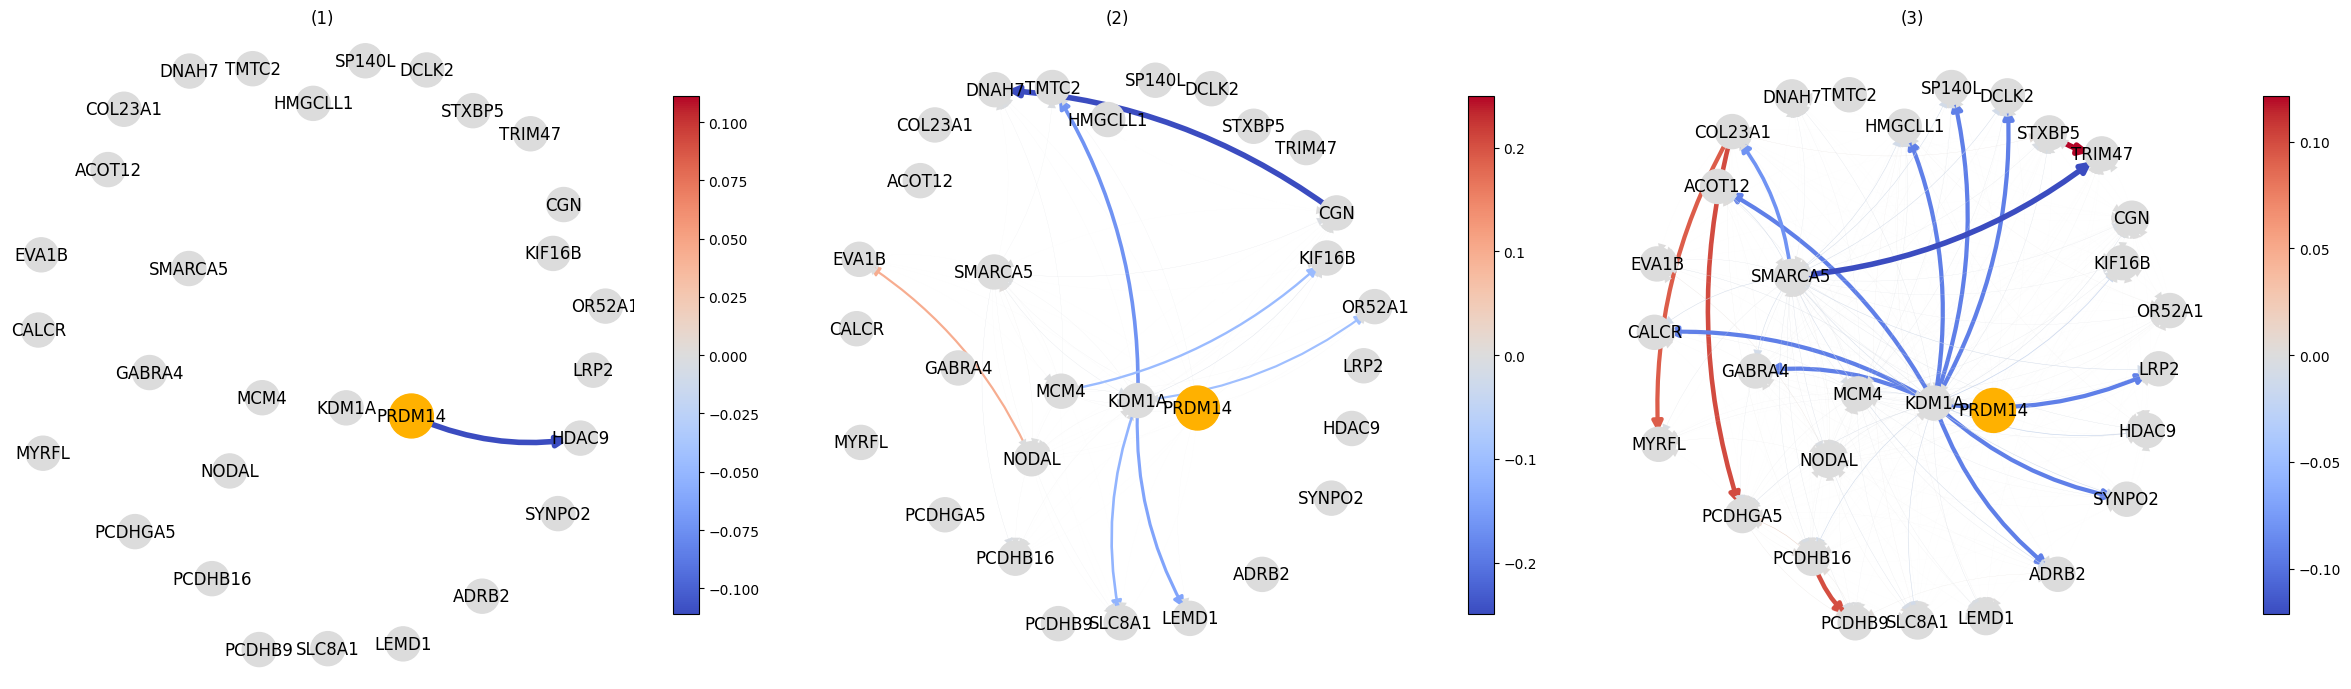

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
# fig.suptitle(
#     f"Shared top-{len(selected_nodes)} node attention subgraphs: knockout of {target_gene}",
#     fontsize=15
# )

cmap = plt.cm.coolwarm

for i, current_hop in enumerate(A_Agg.keys()):

    hop_subgraph = graphs_by_hop[current_hop]
    clean_subgraph = nx.DiGraph()

    # Force all selected nodes to appear in every subplot
    clean_subgraph.add_nodes_from(selected_nodes)

    # Add only hop-specific edges between selected nodes
    for u, v, data in hop_subgraph.edges(data=True):
        if u in selected_nodes and v in selected_nodes:
            clean_subgraph.add_edge(u, v, weight=data["weight"], abs_weight=abs(data["weight"]))

    clean_subgraph.remove_edges_from(nx.selfloop_edges(clean_subgraph))

    plotted_edges = [(u, v, data["weight"], abs(data["weight"])) for u, v, data in clean_subgraph.edges(data=True)]

    pos = shared_pos

    node_colors = ["#ffb100" if node == target_gene else "gainsboro" for node in clean_subgraph.nodes()]
    node_sizes = [1000 if node == target_gene else 600 for node in clean_subgraph.nodes()]

    nx.draw_networkx_nodes(
        clean_subgraph,
        pos,
        ax=axes[i],
        node_color=node_colors,
        node_size=node_sizes,
        edgecolors=None
    )

    nx.draw_networkx_labels(
        clean_subgraph,
        pos,
        ax=axes[i],
        font_size=12
    )

    signed_weights = [w for _, _, w, _ in plotted_edges]
    abs_weights = [abs_w for _, _, _, abs_w in plotted_edges]
    max_abs_w = max(abs_weights) if abs_weights else 1.0
    edge_widths = [(abs_w / max_abs_w) * 4.0 for abs_w in abs_weights]
    vmin = -max_abs_w
    vmax = max_abs_w

    nx.draw_networkx_edges(
        clean_subgraph,
        pos,
        ax=axes[i],
        width=edge_widths,
        edge_color=signed_weights,
        edge_cmap=cmap,
        edge_vmin=vmin,
        edge_vmax=vmax,
        arrowsize=15,
        connectionstyle="arc3,rad=0.15"
    )

    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(vmin=vmin, vmax=vmax)
    )
    sm.set_array([])

    fig.colorbar(sm, ax=axes[i], shrink=0.8)
    axes[i].set_title(
        f"({i+1})"
    )
    axes[i].set_axis_off()

plt.tight_layout()
plt.savefig(f'subgraph_{target_gene}.pdf')
plt.show()

Here, single graph with multiple hops

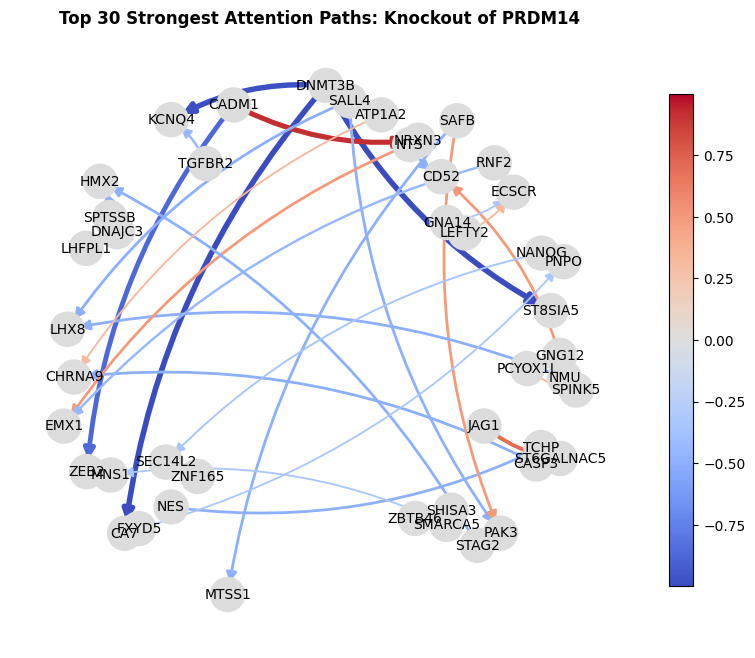

<Figure size 640x480 with 0 Axes>

In [44]:
idx_to_gene = {idx:gene for gene, idx in gene_to_idx.items()}
K_edges = 30

cmap = plt.cm.coolwarm

A = A_Agg['one_hop']
A_dense = A.cpu().detach().numpy()
A_dense[np.abs(A_dense) < minimum_signal] = 0.0

# building networkx digraph from adjacency matrix
attention_graph = nx.from_numpy_array(A_dense, create_using=nx.DiGraph)
attention_graph = nx.relabel_nodes(attention_graph, idx_to_gene)

# NOTE: rimotion of self-loops
attention_graph.remove_edges_from(nx.selfloop_edges(attention_graph))

# Extract Ego-Graph of. target gene
try:
    subgraph = nx.ego_graph(attention_graph, target_gene, radius=2, center=True)
except nx.NodeNotFound:
    print(f"Node {perturbed_gene} has no edges above the noise floor.")
    subgraph = nx.DiGraph()


if len(subgraph.nodes) > 1:
    
    # store signed and absolute weights
    edges_with_weights = [
        (u, v, data['weight'], abs(data['weight'])) 
        for u, v, data in subgraph.edges(data=True)
    ]
    
    # Sort strictly by the absolute magnitude to find the strongest signals
    edges_with_weights.sort(key=lambda x: x[3], reverse=True)
    top_edges = edges_with_weights[:K_edges]
    
    clean_subgraph = nx.DiGraph()
    for u, v, w, abs_w in top_edges:
        clean_subgraph.add_edge(u, v, weight=w, abs_weight=abs_w)
    
    # Visualization Setup
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(clean_subgraph, k=0.2, iterations=60, seed=42)
    node_colors = ["#ffb100" if node == target_gene else "gainsboro" for node in clean_subgraph.nodes()]
    node_sizes = [1000 if node == target_gene else 600 for node in clean_subgraph.nodes()]
    nx.draw_networkx_nodes(clean_subgraph, pos, node_color=node_colors, node_size=node_sizes, edgecolors=None)
    nx.draw_networkx_labels(clean_subgraph, pos, font_size=10)
    
    # dynamic edge syling
    signed_weights = [w for _, _, w, _ in top_edges]
    abs_weights = [abs_w for _, _, _, abs_w in top_edges]
    max_abs_w = max(abs_weights) if abs_weights else 1.0
    edge_widths = [(abs_w / max_abs_w) * 4. for abs_w in abs_weights]
    vmin = -max_abs_w
    vmax = max_abs_w
    
    edge_draw = nx.draw_networkx_edges(
        clean_subgraph, pos,
        width=edge_widths, 
        edge_color=signed_weights, 
        edge_cmap=cmap,
        edge_vmin=vmin,    # Locks the bottom of the colormap to the negative max
        edge_vmax=vmax,    # Locks the top of the colormap to the positive max
        arrowsize=15, 
        connectionstyle='arc3,rad=0.15' # Increased curve to separate bidirectional arrows
    )
    
    # Add Colorbar matched to the diverging scale
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.8)
    #cbar.set_label("Attention Flow (Blue = Negative, Red = Positive)", fontsize=12)
    
    plt.title(f"Top {K_edges} Strongest Attention Paths: Knockout of {target_gene}", fontsize=12, fontweight="bold")
    plt.axis("off")
    plt.show()
else:
    print("Not enough local downstream nodes found.")

plt.tight_layout()
plt.show()


Sankey diagram

In [30]:
K_edges = 15

In [31]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from tqdm import tqdm

# Assuming A_Agg, target_gene, minimum_signal, K_edges, idx_to_gene are already defined

labels = [target_gene]
label_to_idx = {target_gene: 0}
sources = []
targets = []
values = []
link_colors = []
link_customdata = [] # For tooltips

all_signed_weights = []

# --- Step 1: Collect top edges and establish global color bounds ---
top_edges_dict = {}
for current_hop in A_Agg.keys():
    A = A_Agg[current_hop]
    A_dense = A.cpu().detach().numpy()
    A_dense[np.abs(A_dense) < minimum_signal] = 0.0
    
    attention_graph = nx.from_numpy_array(A_dense, create_using=nx.DiGraph)
    attention_graph = nx.relabel_nodes(attention_graph, idx_to_gene)
    attention_graph.remove_edges_from(nx.selfloop_edges(attention_graph))
    
    try:
        subgraph = nx.ego_graph(attention_graph, target_gene, radius=1, center=True)
        edges_with_weights = [
            (u, v, data['weight'], abs(data['weight'])) 
            for u, v, data in subgraph.edges(data=True)
        ]
        # Sort by absolute magnitude
        edges_with_weights.sort(key=lambda x: x[3], reverse=True)
        top_edges = edges_with_weights[:K_edges]
        top_edges_dict[current_hop] = top_edges
        
        all_signed_weights.extend([w for _, _, w, _ in top_edges])
    except nx.NodeNotFound:
        top_edges_dict[current_hop] = []

# Define bounds for the coolwarm colormap
max_abs_w = max([abs(w) for w in all_signed_weights]) if all_signed_weights else 1.0
vmin, vmax = -max_abs_w, max_abs_w

def get_rgba_color(weight, vmin, vmax, alpha=0.5):
    """Maps a signed weight to a coolwarm RGBA string for Plotly."""
    norm_w = (weight - vmin) / (vmax - vmin)
    rgba = plt.cm.coolwarm(norm_w)
    return f'rgba({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)}, {alpha})'

# --- Step 2: Build the Sankey Nodes and Links ---
for current_hop, top_edges in top_edges_dict.items():
    for u, v, w, abs_w in top_edges:
        # Suffix the target node so Plotly places them in distinct sequential columns
        target_name = f"{v} ({current_hop})"
        
        if target_name not in label_to_idx:
            label_to_idx[target_name] = len(labels)
            labels.append(target_name)
            
        sources.append(label_to_idx[target_gene])
        targets.append(label_to_idx[target_name])
        values.append(abs_w)  # Sankey thickness must be positive
        link_colors.append(get_rgba_color(w, vmin, vmax))
        link_customdata.append(w) # Store original signed weight for hover details

# --- Step 3: Render the Interactive Figure ---
fig = go.Figure(data=[go.Sankey(
    node = dict(
        pad = 15,
        thickness = 20,
        line = dict(color = "black", width = 0.5),
        label = labels,
        color = "#2E2E2E" # Dark grey for the nodes
    ),
    link = dict(
        source = sources,
        target = targets,
        value = values,
        color = link_colors,
        customdata = link_customdata,
        # Customize the hover tooltip to show exact biological logic
        hovertemplate = '<b>%{source.label}</b> \u2192 <b>%{target.label}</b><br>Signal Strength: %{value:.4f}<br>Learned Weight: %{customdata:.4f}<extra></extra>'
    )
)])

fig.update_layout(
    title_text=f"SPECTRA Perturbation Shockwave: {target_gene}",
    font_size=12,
    height=800,
    plot_bgcolor='white'
)

fig.show()

In [32]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from tqdm import tqdm

# Assuming A_Agg, target_gene, minimum_signal, K_edges, idx_to_gene are already defined

labels = [target_gene]
label_to_idx = {target_gene: 0}
sources = []
targets = []
values = []
link_colors = []
link_customdata = [] 

all_signed_weights = []

# Dictionary to keep track of which nodes belong in which column
hop_to_nodes = {'0': [target_gene], 'one_hop': [], 'two_hops': [], 'three_hops': []}

# --- Step 1: Collect top edges and establish global color bounds ---
top_edges_dict = {}
for current_hop in A_Agg.keys():
    A = A_Agg[current_hop]
    A_dense = A.cpu().detach().numpy()
    A_dense[np.abs(A_dense) < minimum_signal] = 0.0
    
    attention_graph = nx.from_numpy_array(A_dense, create_using=nx.DiGraph)
    attention_graph = nx.relabel_nodes(attention_graph, idx_to_gene)
    attention_graph.remove_edges_from(nx.selfloop_edges(attention_graph))
    
    try:
        subgraph = nx.ego_graph(attention_graph, target_gene, radius=1, center=True)
        edges_with_weights = [
            (u, v, data['weight'], abs(data['weight'])) 
            for u, v, data in subgraph.edges(data=True)
        ]
        edges_with_weights.sort(key=lambda x: x[3], reverse=True)
        top_edges = edges_with_weights[:K_edges]
        top_edges_dict[current_hop] = top_edges
        
        all_signed_weights.extend([w for _, _, w, _ in top_edges])
    except nx.NodeNotFound:
        top_edges_dict[current_hop] = []

max_abs_w = max([abs(w) for w in all_signed_weights]) if all_signed_weights else 1.0
vmin, vmax = -max_abs_w, max_abs_w

def get_rgba_color(weight, vmin, vmax, alpha=0.5):
    norm_w = (weight - vmin) / (vmax - vmin)
    rgba = plt.cm.coolwarm(norm_w)
    return f'rgba({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)}, {alpha})'

# --- Step 2: Build Nodes and Assign to Hop Groups ---
for current_hop, top_edges in top_edges_dict.items():
    for u, v, w, abs_w in top_edges:
        target_name = f"{v} ({current_hop})"
        
        if target_name not in label_to_idx:
            label_to_idx[target_name] = len(labels)
            labels.append(target_name)
            hop_to_nodes[current_hop].append(target_name)
            
        sources.append(label_to_idx[target_gene])
        targets.append(label_to_idx[target_name])
        values.append(abs_w) 
        link_colors.append(get_rgba_color(w, vmin, vmax))
        link_customdata.append(w)

# --- Step 3: Calculate Explicit X and Y Coordinates ---
node_x = [0.0] * len(labels)
node_y = [0.5] * len(labels)

# Map each hop to a specific X coordinate (0.0 is left, 1.0 is right)
hop_x_map = {'0': 0.01, 'one_hop': 0.33, 'two_hops': 0.66, 'three_hops': 0.99}

for hop_name, nodes_in_hop in hop_to_nodes.items():
    if not nodes_in_hop: 
        continue
        
    x_val = hop_x_map[hop_name]
    
    # Vertically space the nodes evenly based on how many are in this column
    if len(nodes_in_hop) == 1:
        y_vals = [0.5]
    else:
        y_vals = np.linspace(0.05, 0.95, len(nodes_in_hop))
        
    for y_val, node_name in zip(y_vals, nodes_in_hop):
        idx = label_to_idx[node_name]
        node_x[idx] = x_val
        node_y[idx] = y_val

# --- Step 4: Render the Interactive Figure ---
fig = go.Figure(data=[go.Sankey(
    arrangement = "snap",
    node = dict(
        pad = 15,
        thickness = 20,
        line = dict(color = "black", width = 0.5),
        label = labels,
        color = "#2E2E2E",
        x = node_x, # Inject manual X coordinates
        y = node_y  # Inject manual Y coordinates
    ),
    link = dict(
        source = sources,
        target = targets,
        value = values,
        color = link_colors,
        customdata = link_customdata,
        hovertemplate = '<b>%{source.label}</b> \u2192 <b>%{target.label}</b><br>Signal Strength: %{value:.4f}<br>Learned Weight: %{customdata:.4f}<extra></extra>'
    )
)])

fig.update_layout(
    title_text=f"SPECTRA Perturbation Shockwave: {target_gene}",
    font_size=12,
    height=800,
    plot_bgcolor='white'
)

fig.show()

#### **Continuous cascade**

In [42]:
def downstream_A_from_alpha(edge_index, alpha, N, edge_weight=None):
    """
    Builds A[src, dst] for original directed edges src -> dst.
    This is row-source / column-target convention.
    """
    src, dst = edge_index
    deg_in = torch.bincount(dst, minlength=N).float().clamp_min(1.0).to(alpha.device)
    vals = alpha / deg_in[dst]

    if edge_weight is not None:
        vals = vals * edge_weight.to(alpha.device)

    A = torch.sparse_coo_tensor(
        torch.stack([src, dst]),
        vals,
        (N, N),
        device=alpha.device
    ).to_dense()

    return A

@torch.no_grad()
def compute_downstream_path_matrices(model, x, pert):
    model.eval()

    y_hat, x_hat, (a1, a2, a3) = model(
        (x, pert),
        return_attention_weights=True
    )

    B = pert.shape[0]
    N = model.num_nodes
    E = model.edge_index.shape[1]

    alpha1 = a1["alpha_in"].view(B, E)
    alpha2 = a2["alpha_in"].view(B, E)
    alpha3 = a3["alpha_in"].view(B, E)

    A1_sum = torch.zeros(N, N, device=model.device)
    A2_sum = torch.zeros(N, N, device=model.device)
    A3_sum = torch.zeros(N, N, device=model.device)

    for b in range(B):
        A1 = downstream_A_from_alpha(model.edge_index, alpha1[b], N)
        A2 = downstream_A_from_alpha(model.edge_index, alpha2[b], N)
        A3 = downstream_A_from_alpha(model.edge_index, alpha3[b], N)

        A1_sum += A1
        A2_sum += A2
        A3_sum += A3

    return (A1_sum / B, A2_sum / B, A3_sum / B)

In [43]:
minimum_signal = 1e-4
K_edges = 30
model.eval()

# perturbation to analyze
target_gene = "PRDM14" 
if target_gene not in gene_to_idx:
    raise ValueError(f"Gene '{target_gene}' not found in gene mapping.")
target_idx = gene_to_idx[target_gene]

# Iterate batches through the loader to find the specific perturbation
for x, y, pert, pert_idx in test_loader:
    if pert_idx[0].item() == model_config['pert_to_idx'][target_gene]:
        target_batch = (x, y, pert, pert_idx)
        break

if target_batch is None:
    raise ValueError(f"Batch for perturbation '{target_gene}' not found in test_loader.")

x, y, pert, pert_idx = target_batch
x = x.to(model.device)
y = y.to(model.device)
pert = pert.to(model.device)
idx_to_gene = {idx:gene for gene, idx in gene_to_idx.items()}


# attention graphs
A_1, A_2, A_3 = compute_downstream_path_matrices(model, x, pert)

In [44]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# --- Assume A_1, A_2, A_3 are available from your SPECTRA model ---
# A_layers = [A_1, A_2, A_3] 
# (Make sure they are in order of propagation)

labels = []
label_to_idx = {}
sources = []
targets = []
values = []
link_colors = []
link_customdata = []

all_signed_weights = []

def get_node_name(gene, hop):
    if hop == 0:
        return gene
    return f"{gene} ({hop}-hop)"

def get_node_idx(node_name):
    if node_name not in label_to_idx:
        label_to_idx[node_name] = len(labels)
        labels.append(node_name)
    return label_to_idx[node_name]

# Initialize the cascade with the perturbed target gene
current_sources = {target_gene}

# --- Step 1: Extract the continuous cascading edges ---
cascade_edges = [] # Store as (source_name, target_name, signed_weight, abs_weight)

for hop_idx, A in enumerate([A_1, A_2, A_3]):
    current_hop_num = hop_idx + 1
    
    A_dense = A.cpu().detach().numpy()
    A_dense[np.abs(A_dense) < minimum_signal] = 0.0
    
    G = nx.from_numpy_array(A_dense, create_using=nx.DiGraph)
    G = nx.relabel_nodes(G, idx_to_gene)
    G.remove_edges_from(nx.selfloop_edges(G))
    
    next_sources = set()
    layer_edges = []
    
    # Only look at edges flowing OUT of the genes we reached in the previous hop
    for source_gene in current_sources:
        if source_gene in G:
            for target_gene_dest in G.successors(source_gene):
                w = G[source_gene][target_gene_dest]['weight']
                layer_edges.append((source_gene, target_gene_dest, w, abs(w)))
                
    # Sort by strongest absolute signal and take top K
    layer_edges.sort(key=lambda x: x[3], reverse=True)
    top_layer_edges = layer_edges[:K_edges]
    
    # Format the names and add to our master cascade
    for src, tgt, w, abs_w in top_layer_edges:
        src_name = get_node_name(src, current_hop_num - 1)
        tgt_name = get_node_name(tgt, current_hop_num)
        
        cascade_edges.append((src_name, tgt_name, w, abs_w))
        next_sources.add(tgt) # These targets become the sources for the next hop!
        all_signed_weights.append(w)
        
    current_sources = next_sources

# --- Step 2: Global Color Bounds for Heterophily ---
max_abs_w = max([abs(w) for w in all_signed_weights]) if all_signed_weights else 1.0
vmin, vmax = -max_abs_w, max_abs_w

def get_rgba_color(weight, vmin, vmax, alpha=0.55):
    norm_w = (weight - vmin) / (vmax - vmin)
    rgba = plt.cm.coolwarm(norm_w)
    return f'rgba({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)}, {alpha})'

# --- Step 3: Build Sankey Data ---
for src_name, tgt_name, w, abs_w in cascade_edges:
    sources.append(get_node_idx(src_name))
    targets.append(get_node_idx(tgt_name))
    values.append(abs_w)
    link_colors.append(get_rgba_color(w, vmin, vmax))
    link_customdata.append(w)

# --- Step 4: Render the Interactive Figure ---
fig = go.Figure(data=[go.Sankey(
    arrangement = "snap",
    node = dict(
        pad = 20,
        thickness = 20,
        line = dict(color = "black", width = 0.5),
        label = labels,
        color = "#2E2E2E"
    ),
    link = dict(
        source = sources,
        target = targets,
        value = values,
        color = link_colors,
        customdata = link_customdata,
        hovertemplate = '<b>%{source.label}</b> \u2192 <b>%{target.label}</b><br>Abs Signal Flow: %{value:.4f}<br>Learned Weight: %{customdata:.4f}<extra></extra>'
    )
)])

fig.update_layout(
    title_text=f"SPECTRA Continuous Perturbation Cascade: {target_gene}",
    font_size=12,
    height=800,
    plot_bgcolor='white'
)

fig.show()

In [52]:
network_genes = [label.split(' (')[0] for label in labels]

In [55]:
import gseapy as gp

# 1. Extract the list of unique genes currently in your Sankey network
# (Replace this with the actual list of genes extracted from your subgraph)
# network_genes = ['PRDM14', 'HDAC9', 'DPF1', 'ZNF296', 'CADM1', 'DNAH7', 'SALL4', 'SEMA6A']

target_gene = 'PRDM14'

# 2. Query Enrichr for GO Biological Processes
print("Querying Gene Ontology...")
enr = gp.enrichr(gene_list=network_genes,
                 gene_sets='GO_Biological_Process_2023', # Or 2021 depending on the latest available
                 organism='human', # Change to 'mouse' if working with murine data
                 outdir=None)

# 3. Get the top N most significant biological processes in your network
# We look at the top 6 to ensure we have enough diversity for coloring
top_pathways = enr.results.head(6)

# 4. Build the gene_to_function dictionary
gene_to_function = {}

for gene in network_genes:
    assigned = False
    
    # Check if the gene belongs to any of our top significant pathways
    for idx, row in top_pathways.iterrows():
        # gseapy returns matching genes as a string separated by ';'
        pathway_genes = row['Genes'].split(';')
        
        if gene in pathway_genes:
            # Clean up the GO term name for display (e.g., removes the '(GO:0001234)' string)
            clean_name = row['Term'].split(' (GO:')[0]
            
            # Capitalize it nicely for the plot legend
            clean_name = clean_name.capitalize() 
            
            gene_to_function[gene] = clean_name
            assigned = True
            break # Once assigned to its most significant pathway, move to next gene
            
    # If the gene doesn't map to the top enriched terms, give it a default label
    if not assigned:
        gene_to_function[gene] = 'Other / Pleiotropic'

# 5. Always force the perturbed target to be distinct
gene_to_function[target_gene] = 'Perturbed Target'

# --- Let's see the result! ---
for gene, func in gene_to_function.items():
    print(f"{gene.ljust(10)} : {func}")

Querying Gene Ontology...
PRDM14     : Perturbed Target
HDAC9      : Peptidyl-lysine deacetylation
ZNF296     : Other / Pleiotropic
SLC2A12    : Other / Pleiotropic
TMEM158    : Other / Pleiotropic
GPSM2      : Other / Pleiotropic
BEND3      : Other / Pleiotropic
DPF1       : Other / Pleiotropic
AJAP1      : Other / Pleiotropic
PRR36      : Other / Pleiotropic
PLCH1      : Other / Pleiotropic
ITFG2      : Other / Pleiotropic
ITGA5      : Other / Pleiotropic
STX4       : Other / Pleiotropic
PTBP1      : Other / Pleiotropic
TRIM71     : Other / Pleiotropic
APPL2      : Other / Pleiotropic
PMM2       : Other / Pleiotropic
BCAP29     : Other / Pleiotropic
BRINP1     : Other / Pleiotropic
MGA        : Other / Pleiotropic
FGD4       : Other / Pleiotropic
MTA3       : Protein deacetylation
UNG        : Other / Pleiotropic
ZSCAN2     : Other / Pleiotropic
CLUH       : Other / Pleiotropic
TLCD1      : Other / Pleiotropic
SIRT1      : Peptidyl-lysine deacetylation
GREB1      : Other / Pleiotropi

In [47]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import matplotlib.colors as mcolors

# A_layers = [A_1, A_2, A_3] 

# # Define Functional Groups - Gene Ontology (GO) databases
# gene_to_function = {
#     target_gene: 'Perturbed Target',
#     'HDAC9': 'Chromatin Remodeling',
#     'DPF1': 'Chromatin Remodeling',
#     'ZNF296': 'Gametogenesis',
#     'CADM1': 'Neurodevelopment',
#     'DNAH7': 'Gametogenesis',
#     'SALL4': 'Pluripotency'
#     # Any gene not in this dictionary will be marked as 'Other / Unannotated'
# }

# Automatically generate a color palette for your functional groups
unique_groups = list(set(gene_to_function.values())) + ['Other / Unannotated']
palette = plt.cm.Pastel1.colors
group_colors = {
    group: f'rgba({int(c[0]*255)}, {int(c[1]*255)}, {int(c[2]*255)}, 0.9)'
    for group, c in zip(unique_groups, palette)
}
group_colors['Perturbed Target'] = 'rgba(50, 50, 50, 0.9)' # Dark grey for the target

# Track Internal IDs vs Display Labels
internal_id_to_idx = {}
display_labels = []
node_colors = []
node_customdata = [] # To show functional group on hover

sources, targets, values, link_colors, link_customdata = [], [], [], [], []
all_signed_weights = []

def get_internal_id(gene, hop):
    return f"{gene}_hop{hop}"

def add_or_get_node(gene, hop):
    internal_id = get_internal_id(gene, hop)
    if internal_id not in internal_id_to_idx:
        internal_id_to_idx[internal_id] = len(display_labels)
        
        # Plotly only sees the clean name!
        display_labels.append(gene) 
        
        # Assign Node Color based on function
        func_group = gene_to_function.get(gene, 'Other / Unannotated')
        node_colors.append(group_colors[func_group])
        node_customdata.append(func_group)
        
    return internal_id_to_idx[internal_id]

current_sources = {target_gene}
cascade_edges = [] 

# Step 3: Extract the continuous cascading edges
for hop_idx, A in enumerate([A_1, A_2, A_3]):
    current_hop_num = hop_idx + 1
    
    A_dense = A.cpu().detach().numpy()
    A_dense[np.abs(A_dense) < minimum_signal] = 0.0
    
    G = nx.from_numpy_array(A_dense, create_using=nx.DiGraph)
    G = nx.relabel_nodes(G, idx_to_gene)
    G.remove_edges_from(nx.selfloop_edges(G))
    
    next_sources = set()
    layer_edges = []
    
    for source_gene in current_sources:
        if source_gene in G:
            for target_gene_dest in G.successors(source_gene):
                w = G[source_gene][target_gene_dest]['weight']
                layer_edges.append((source_gene, target_gene_dest, w, abs(w)))
                
    layer_edges.sort(key=lambda x: x[3], reverse=True)
    top_layer_edges = layer_edges[:K_edges]
    
    for src, tgt, w, abs_w in top_layer_edges:
        src_idx = add_or_get_node(src, current_hop_num - 1)
        tgt_idx = add_or_get_node(tgt, current_hop_num)
        
        cascade_edges.append((src_idx, tgt_idx, w, abs_w))
        next_sources.add(tgt) 
        all_signed_weights.append(w)
        
    current_sources = next_sources

# Edge Colors (Heterophily)
max_abs_w = max([abs(w) for w in all_signed_weights]) if all_signed_weights else 1.0
vmin, vmax = -max_abs_w, max_abs_w

def get_edge_color(weight, vmin, vmax, alpha=0.4):
    norm_w = (weight - vmin) / (vmax - vmin)
    rgba = plt.cm.coolwarm(norm_w)
    return f'rgba({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)}, {alpha})'

for src_idx, tgt_idx, w, abs_w in cascade_edges:
    sources.append(src_idx)
    targets.append(tgt_idx)
    values.append(abs_w)
    link_colors.append(get_edge_color(w, vmin, vmax))
    link_customdata.append(w)

# Step 5: Render
fig = go.Figure(data=[go.Sankey(
    arrangement = "snap",
    node = dict(
        pad = 20,
        thickness = 20,
        line = dict(color = "black", width = 0.5),
        label = display_labels,       # Clean names!
        color = node_colors,          # Functional coloring!
        customdata = node_customdata,
        hovertemplate = '<b>%{label}</b><br>Group: %{customdata}<extra></extra>'
    ),
    link = dict(
        source = sources,
        target = targets,
        value = values,
        color = link_colors,
        customdata = link_customdata,
        hovertemplate = '<b>%{source.label}</b> \u2192 <b>%{target.label}</b><br>Signal Flow: %{value:.4f}<br>Learned Weight: %{customdata:.4f}<extra></extra>'
    )
)])

fig.update_layout(
    title_text=f"SPECTRA Perturbation Cascade: {target_gene} (Colored by Pathway)",
    title_x=0.5,
    font_size=12,
    height=800,
    plot_bgcolor='white'
)

fig.show()

In [67]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# --- Assume A_1, A_2, A_3 and gene_to_function are already defined ---

# --- 1. Colors & Legend Setup ---
unique_groups = sorted(list(set(gene_to_function.values())))
if 'Perturbed Target' in unique_groups:
    unique_groups.remove('Perturbed Target')
    unique_groups.insert(0, 'Perturbed Target') # Keep Target at the top of the legend

palette = plt.cm.Set2.colors # Set2 is great for distinct categorical colors
group_colors = {}
for i, group in enumerate(unique_groups):
    if group == 'Perturbed Target':
        group_colors[group] = 'rgba(50, 50, 50, 0.9)'
    elif group == 'Other / Pleiotropic':
        group_colors[group] = 'rgba(200, 200, 200, 0.6)'
    else:
        c = palette[i % len(palette)]
        group_colors[group] = f'rgba({int(c[0]*255)}, {int(c[1]*255)}, {int(c[2]*255)}, 0.9)'

# --- 2. Track Nodes by Hop for Sorting ---
# We track which genes are in which hop so we can sort them by function later
hop_to_genes = {0: set([target_gene]), 1: set(), 2: set(), 3: set()}
cascade_edges = [] 
all_signed_weights = []

current_sources = {target_gene}

for hop_idx, A in enumerate([A_1, A_2, A_3]):
    current_hop_num = hop_idx + 1
    A_dense = A.cpu().detach().numpy()
    A_dense[np.abs(A_dense) < minimum_signal] = 0.0
    
    G = nx.from_numpy_array(A_dense, create_using=nx.DiGraph)
    G = nx.relabel_nodes(G, idx_to_gene)
    G.remove_edges_from(nx.selfloop_edges(G))
    
    next_sources = set()
    layer_edges = []
    
    for source_gene in current_sources:
        if source_gene in G:
            for target_gene_dest in G.successors(source_gene):
                w = G[source_gene][target_gene_dest]['weight']
                layer_edges.append((source_gene, target_gene_dest, w, abs(w)))
                
    layer_edges.sort(key=lambda x: x[3], reverse=True)
    top_layer_edges = layer_edges[:K_edges]
    
    for src, tgt, w, abs_w in top_layer_edges:
        cascade_edges.append((src, current_hop_num - 1, tgt, current_hop_num, w, abs_w))
        next_sources.add(tgt)
        hop_to_genes[current_hop_num].add(tgt)
        all_signed_weights.append(w)
        
    current_sources = next_sources

# --- 3. Sort Nodes by Function & Calculate Coordinates ---
node_id_to_idx = {}
display_labels = []
node_colors = []
node_x = []
node_y = []

# X-axis mapping for the hops
hop_x_map = {0: 0.01, 1: 0.33, 2: 0.66, 3: 0.99}

for hop_num in range(4):
    genes_in_hop = list(hop_to_genes[hop_num])
    
    # SORTING MAGIC: Sort genes primarily by their GO term, then alphabetically by name
    genes_in_hop.sort(key=lambda g: (gene_to_function.get(g, 'Other / Pleiotropic'), g))
    
    # Calculate Y coordinates to distribute them evenly in the column
    if len(genes_in_hop) == 1:
        y_vals = [0.5]
    elif len(genes_in_hop) > 1:
        y_vals = np.linspace(0.05, 0.95, len(genes_in_hop))
    else:
        y_vals = []
        
    for gene, y_val in zip(genes_in_hop, y_vals):
        unique_id = f"{gene}_hop{hop_num}"
        node_id_to_idx[unique_id] = len(display_labels)
        
        display_labels.append(gene)
        func_group = gene_to_function.get(gene, 'Other / Pleiotropic')
        node_colors.append(group_colors[func_group])
        
        node_x.append(hop_x_map[hop_num])
        node_y.append(y_val)

# --- 4. Map Edges ---
sources, targets, values, link_colors = [], [], [], []
max_abs_w = max([abs(w) for w in all_signed_weights]) if all_signed_weights else 1.0
vmin, vmax = -max_abs_w, max_abs_w

for src, src_hop, tgt, tgt_hop, w, abs_w in cascade_edges:
    sources.append(node_id_to_idx[f"{src}_hop{src_hop}"])
    targets.append(node_id_to_idx[f"{tgt}_hop{tgt_hop}"])
    values.append(abs_w)
    
    # Edge color logic (coolwarm mapping)
    norm_w = (w - vmin) / (vmax - vmin)
    rgba = plt.cm.coolwarm(norm_w)
    link_colors.append(f'rgba({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)}, 0.4)')

# --- 5. Render Figure with Dummy Legend ---
fig = go.Figure()

# Add the actual Sankey trace
fig.add_trace(go.Sankey(
    arrangement = "fixed", # Forces Plotly to respect our manual X and Y coordinates
    node = dict(
        pad = 15, thickness = 20,
        line = dict(color = "black", width = 0.5),
        label = display_labels,
        color = node_colors,
        x = node_x, # Apply sorted X coords
        y = node_y  # Apply sorted Y coords
    ),
    link = dict(source = sources, target = targets, value = values, color = link_colors)
))

# Add invisible dummy traces to force the Legend to appear
for group in unique_groups:
    fig.add_trace(go.Scatter(
        x=[None], y=[None], 
        mode='markers',
        marker=dict(size=12, color=group_colors[group], symbol='square'),
        legendgroup=group,
        showlegend=True,
        name=group
    ))

fig.update_layout(
    title_text=f"SPECTRA Functional Cascade: {target_gene}",
    title_x=0.5,
    font_size=12,
    height=700,
    plot_bgcolor='white',
    xaxis=dict(visible=False, showgrid=False, zeroline=False),
    yaxis=dict(visible=False, showgrid=False, zeroline=False),
    legend=dict(
        title="Gene Ontology Terms",
        yanchor="top", y=0.99,
        xanchor="left", x=1.05 # Positions legend cleanly to the right of the plot
    )
)

fig.show()

In [49]:
K_edges = 15

In [50]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# --- Assume A_1, A_2, A_3 and gene_to_function are already defined ---

# --- 1. Colors & Legend Setup ---
unique_groups = sorted(list(set(gene_to_function.values())))
if 'Perturbed Target' in unique_groups:
    unique_groups.remove('Perturbed Target')
    unique_groups.insert(0, 'Perturbed Target')

palette = plt.cm.Set2.colors
group_colors = {}
for i, group in enumerate(unique_groups):
    if group == 'Perturbed Target':
        group_colors[group] = 'rgba(50, 50, 50, 0.9)'
    elif group == 'Other / Pleiotropic':
        group_colors[group] = 'rgba(200, 200, 200, 0.6)'
    else:
        c = palette[i % len(palette)]
        group_colors[group] = f'rgba({int(c[0]*255)}, {int(c[1]*255)}, {int(c[2]*255)}, 0.9)'

# --- 2. Track Nodes by Hop for Sorting ---
hop_to_genes = {0: set([target_gene]), 1: set(), 2: set(), 3: set()}
cascade_edges = [] 
all_signed_weights = []

current_sources = {target_gene}

for hop_idx, A in enumerate([A_1, A_2, A_3]):
    current_hop_num = hop_idx + 1
    A_dense = A.cpu().detach().numpy()
    A_dense[np.abs(A_dense) < minimum_signal] = 0.0
    
    G = nx.from_numpy_array(A_dense, create_using=nx.DiGraph)
    G = nx.relabel_nodes(G, idx_to_gene)
    G.remove_edges_from(nx.selfloop_edges(G))
    
    next_sources = set()
    layer_edges = []
    
    for source_gene in current_sources:
        if source_gene in G:
            for target_gene_dest in G.successors(source_gene):
                w = G[source_gene][target_gene_dest]['weight']
                layer_edges.append((source_gene, target_gene_dest, w, abs(w)))
                
    layer_edges.sort(key=lambda x: x[3], reverse=True)
    top_layer_edges = layer_edges[:K_edges]
    
    for src, tgt, w, abs_w in top_layer_edges:
        cascade_edges.append((src, current_hop_num - 1, tgt, current_hop_num, w, abs_w))
        next_sources.add(tgt)
        hop_to_genes[current_hop_num].add(tgt)
        all_signed_weights.append(w)
        
    current_sources = next_sources

# --- 3. Sort Nodes by Function & Calculate Expanding "Cone" Coordinates ---
node_id_to_idx = {}
display_labels = []
node_colors = []
node_x = []
node_y = []

# X-axis mapping for columns
hop_x_map = {0: 0.01, 1: 0.33, 2: 0.66, 3: 0.99}

# MAGIC STEP: Define the vertical boundaries for the triangle shape
# Hop 0 is a point, Hop 1 is tight, Hop 2 expands, Hop 3 is wide open
hop_y_bounds = {
    0: (0.5, 0.5),
    1: (0.32, 0.68),
    2: (0.15, 0.85),
    3: (0.02, 0.98)
}

for hop_num in range(4):
    genes_in_hop = list(hop_to_genes[hop_num])
    
    # Sort primarily by functional group, then by name
    genes_in_hop.sort(key=lambda g: (gene_to_function.get(g, 'Other / Pleiotropic'), g))
    
    y_min, y_max = hop_y_bounds[hop_num]
    
    if len(genes_in_hop) == 1:
        y_vals = [(y_min + y_max) / 2.0]
    elif len(genes_in_hop) > 1:
        y_vals = np.linspace(y_min, y_max, len(genes_in_hop))
    else:
        y_vals = []
        
    for gene, y_val in zip(genes_in_hop, y_vals):
        unique_id = f"{gene}_hop{hop_num}"
        node_id_to_idx[unique_id] = len(display_labels)
        
        display_labels.append(gene)
        func_group = gene_to_function.get(gene, 'Other / Pleiotropic')
        node_colors.append(group_colors[func_group])
        
        node_x.append(hop_x_map[hop_num])
        node_y.append(y_val)

# --- 4. Map Edges ---
sources, targets, values, link_colors = [], [], [], []
max_abs_w = max([abs(w) for w in all_signed_weights]) if all_signed_weights else 1.0
vmin, vmax = -max_abs_w, max_abs_w

for src, src_hop, tgt, tgt_hop, w, abs_w in cascade_edges:
    sources.append(node_id_to_idx[f"{src}_hop{src_hop}"])
    targets.append(node_id_to_idx[f"{tgt}_hop{tgt_hop}"])
    values.append(abs_w)
    
    norm_w = (w - vmin) / (vmax - vmin)
    rgba = plt.cm.coolwarm(norm_w)
    link_colors.append(f'rgba({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)}, 0.4)')

# --- 5. Render Final Figure ---
fig = go.Figure()

fig.add_trace(go.Sankey(
    arrangement = "fixed", # Force explicit geometry positioning
    node = dict(
        pad = 14, thickness = 22,
        line = dict(color = "black", width = 0.5),
        label = display_labels,
        color = node_colors,
        x = node_x,
        y = node_y 
    ),
    link = dict(source = sources, target = targets, value = values, color = link_colors)
))

# Hacked Legend Traces
for group in unique_groups:
    fig.add_trace(go.Scatter(
        x=[None], y=[None], 
        mode='markers',
        marker=dict(size=11, color=group_colors[group], symbol='square'),
        legendgroup=group,
        showlegend=True,
        name=group
    ))

fig.update_layout(
    #title_text=f"SPECTRA Perturbation Shockwave: {target_gene}",
    #font_size=12,
    font=dict(size=24, family="Arial"),
    width=2400,
    height=1200,
    plot_bgcolor='white',
    # Keep background coordinates hidden
    xaxis=dict(visible=False, showgrid=False, zeroline=False),
    yaxis=dict(visible=False, showgrid=False, zeroline=False),
#     legend=dict(
#         # title="Gene Ontology Terms",
#         font=dict(size=8, family="Arial"),
#         yanchor="top", y=0.99,
#         xanchor="left", x=1.05
#     )
)
# output_pdf_path = f"spectra_cascade_{target_gene}.pdf"
# fig.write_image(output_pdf_path, format="pdf")
fig.show()

***

### **Other plots - UMAP**


In [59]:
# umap plot
def plot_perturbation_umap(
    real_adata,
    pred_adata,
    perturbation,
    pert_key="target_gene",
    control_label="non-targeting",
    use_rep=None,
    n_neighbors=15,
    min_dist=0.4,
    random_state=0,
    point_size=18,
    figsize=(10, 10),
):
    """
    Plot UMAP comparing ground-truth and SPECTRA-predicted cells for one perturbation.

    Assumes:
      - real_adata contains real control + real perturbed cells
      - pred_adata contains predicted perturbed cells, optionally same controls
      - both share genes and perturbation labels in .obs[pert_key]
    """

    gt = real_adata.copy()
    pred = pred_adata.copy()

    # keep common genes in same order
    common_genes = gt.var_names.intersection(pred.var_names)
    gt = gt[:, common_genes].copy()
    pred = pred[:, common_genes].copy()

    gt.obs["_source"] = "ground_truth"
    pred.obs["_source"] = "predicted"

    # remove duplicated controls from pred if present
    pred = pred[pred.obs[pert_key].astype(str) != control_label].copy()

    # concatenate
    combined = ad.concat([gt, pred], axis=0, join="inner", label="_dataset", keys=["gt", "pred"], index_unique="-")

    labels = combined.obs[pert_key].astype(str)
    source = combined.obs["_source"].astype(str)

    combined.obs["_plot_group"] = "Other cells"
    combined.obs.loc[
        (labels == perturbation) & (source == "ground_truth"),
        "_plot_group"
    ] = f"{perturbation} ground truth"

    combined.obs.loc[
        (labels == perturbation) & (source == "predicted"),
        "_plot_group"
    ] = f"{perturbation} predicted"

    # preprocessing / UMAP
    if "X_umap" not in combined.obsm:
        # sc.pp.normalize_total(combined, target_sum=1e4)
        # sc.pp.log1p(combined)

        if use_rep is None:
            # sc.pp.highly_variable_genes(combined, n_top_genes=2000, subset=True)
            # sc.pp.scale(combined, max_value=10)
            sc.tl.pca(combined, svd_solver="arpack")
            use_rep = "X_pca"

        sc.pp.neighbors(
            combined,
            n_neighbors=n_neighbors,
            use_rep=use_rep,
            random_state=random_state,
        )
        sc.tl.umap(combined, min_dist=min_dist, random_state=random_state)

    # colors
    palette = {
        "Other cells": "lightgrey",
        f"{perturbation} ground truth": "red",
        f"{perturbation} predicted": "dodgerblue",
    }

    order = [
        "Other cells",
        f"{perturbation} ground truth",
        f"{perturbation} predicted",
    ]

    fig, ax = plt.subplots(figsize=figsize)

    for group in order:
        mask = combined.obs["_plot_group"].values == group
        xy = combined.obsm["X_umap"][mask]

        ax.scatter(
            xy[:, 0],
            xy[:, 1],
            s=point_size,
            c=palette[group],
            label=group,
            alpha=0.9 if group != "Other cells" else 0.45,
            linewidths=0,
        )

    ax.set_title(perturbation, fontstyle="italic", fontsize=16)

    # ax.set_xticks([])
    # ax.set_yticks([])
    # ax.set_xlabel("UMAP")
    # ax.set_ylabel("UMAP")

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("UMAP", fontsize=12)
    ax.set_ylabel("")

    ax.legend(frameon=False, loc="best")
    #sc.pl._utils.savefig_or_show("perturbation_umap", show=False)

    plt.show()

    return combined

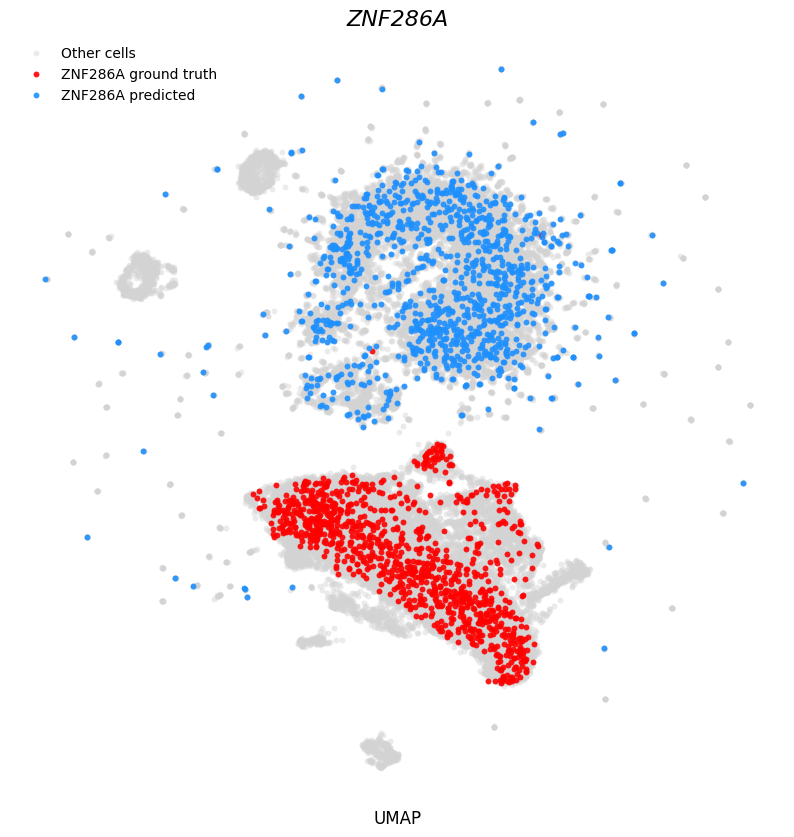

In [60]:
combined_med9 = plot_perturbation_umap(
    real_adata=real_adata,
    pred_adata=pred_adata,
    perturbation="ZNF286A"
)

In [69]:
# BY GEMINI
import scanpy as sc
import anndata as ad
import pandas as pd
import matplotlib.pyplot as plt

def plot_spectra_umap(adata_true, adata_pred, target_pert, pert_column='condition'):
    """
    Plots a UMAP highlighting predicted vs. ground-truth cells for a specific perturbation.
    
    Parameters:
    -----------
    adata_true : anndata.AnnData
        The ground truth dataset containing control and true perturbed cells.
    adata_pred : anndata.AnnData
        The SPECTRA-predicted dataset.
    target_pert : str
        The name of the perturbation to visualize (e.g., 'MED9').
    pert_column : str
        The name of the column in adata.obs that contains the perturbation labels.
    """
    
    # 1. Create the Background: All ground-truth cells EXCEPT the target perturbation
    adata_bg = adata_true[adata_true.obs[pert_column] == 'non-targeting'].copy()
    adata_bg.obs['plot_group'] = 'Background'
    
    # 2. Extract the Ground-Truth target cells
    adata_target_true = adata_true[adata_true.obs[pert_column] == target_pert].copy()
    adata_target_true.obs['plot_group'] = f'True {target_pert}'
    
    # 3. Extract the Predicted target cells
    adata_target_pred = adata_pred[adata_pred.obs[pert_column] == target_pert].copy()
    adata_target_pred.obs['plot_group'] = f'Predicted {target_pert}'
    
    # 4. Concatenate the datasets
    # Using join='inner' ensures only shared genes/features are kept
    adata_combined = ad.concat(
        [adata_bg, adata_target_pred, adata_target_true], 
        join='inner'
    )
    
    # 5. Set up the categorical grouping and Z-order
    # Defining the categories in this specific order ensures the plotting hierarchy
    categories = ['Background', f'Predicted {target_pert}', f'True {target_pert}']
    adata_combined.obs['plot_group'] = pd.Categorical(
        adata_combined.obs['plot_group'], 
        categories=categories, 
        ordered=True
    )
    
    # Sort the AnnData object by this category so Background is drawn first (bottom),
    # Predicted is drawn next, and True is drawn last (top).
    adata_combined = adata_combined[adata_combined.obs.sort_values('plot_group').index].copy()
    
    # 6. Recompute the UMAP on the shared space
    # (Assuming .X contains normalized/log-transformed data suitable for PCA)
    sc.pp.pca(adata_combined)
    sc.pp.neighbors(adata_combined)
    sc.tl.umap(adata_combined)
    
    # 7. Define the color palette
    color_map = {
        'Background': '#e0e0e0',                # Light Grey
        f'Predicted {target_pert}': '#87CEFA',  # Light Blue
        f'True {target_pert}': '#d62728'        # Red
    }
    palette = [color_map[c] for c in categories]
    
    # 8. Generate the plot
    fig, ax = plt.subplots(figsize=(10, 8))
    sc.pl.umap(
        adata_combined,
        color='plot_group',
        palette=palette,
        title=f'SPECTRA Prediction vs Ground Truth: {target_pert}',
        size=60,               # Adjust dot size based on your cell count
        alpha=0.8,             # Slight transparency to see overlapping distributions
        frameon=False,
        sort_order=False,      # Critical: Forces Scanpy to respect our manual row sorting above
        ax=ax,
        show=False
    )
    
    plt.tight_layout()
    plt.show()
    
    return adata_combined

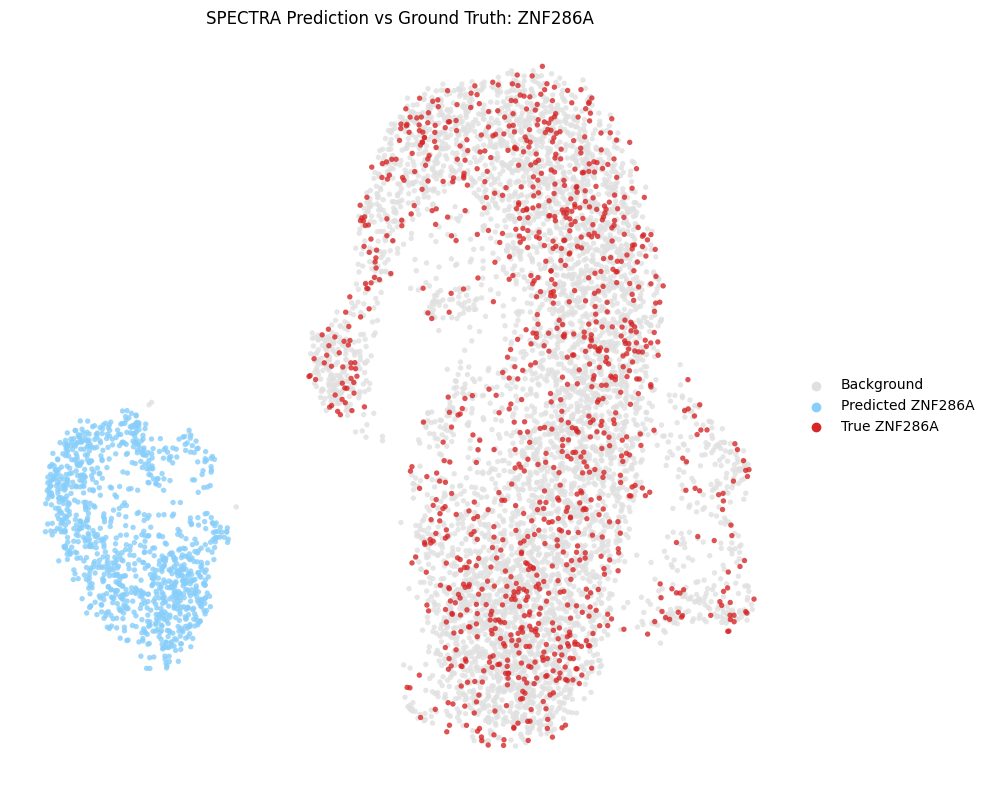

In [70]:
# Call the function for MED9
combined_adata = plot_spectra_umap(
    adata_true=real_adata, 
    adata_pred=pred_adata, 
    target_pert='ZNF286A', 
    pert_column='target_gene'
)

### **Other plots - pred vs real**


In [62]:
from scipy import sparse
from matplotlib import pyplot as plt


def plot_top_de_gene_expression(
    gt_adata,
    pred_adata,
    perturbation,
    K=100,
    pert_key="target_gene",
    control_label="control",
    gene_names=None,
    point_size=35,
    figsize=(10, 10),
):
    """
    For one perturbation, plot average ground-truth expression vs average
    predicted expression for the top K ground-truth DE genes.

    Top DE genes are selected by absolute mean expression shift:
        |mean(gt perturbed) - mean(gt control)|
    """

    # align genes
    common_genes = gt_adata.var_names.intersection(pred_adata.var_names)
    gt = gt_adata[:, common_genes]
    pred = pred_adata[:, common_genes]

    genes = np.array(common_genes)

    def mean_expr(adata, mask):
        X = adata[mask].X
        if sparse.issparse(X):
            return np.asarray(X.mean(axis=0)).ravel()
        return np.asarray(X).mean(axis=0)

    gt_labels = gt.obs[pert_key].astype(str)
    pred_labels = pred.obs[pert_key].astype(str)

    gt_pert_mask = gt_labels == perturbation
    gt_ctrl_mask = gt_labels == control_label
    pred_pert_mask = pred_labels == perturbation

    if gt_pert_mask.sum() == 0:
        raise ValueError(f"No ground-truth cells found for perturbation '{perturbation}'")
    if pred_pert_mask.sum() == 0:
        raise ValueError(f"No predicted cells found for perturbation '{perturbation}'")
    if gt_ctrl_mask.sum() == 0:
        raise ValueError(f"No control cells found with label '{control_label}'")

    gt_pert_mean = mean_expr(gt, gt_pert_mask)
    gt_ctrl_mean = mean_expr(gt, gt_ctrl_mask)
    pred_pert_mean = mean_expr(pred, pred_pert_mask)

    # top K ground-truth DE genes
    de_score = np.abs(gt_pert_mean - gt_ctrl_mean)
    top_idx = np.argsort(de_score)[::-1][:K]

    x = gt_pert_mean[top_idx]
    y = pred_pert_mean[top_idx]
    top_genes = genes[top_idx]

    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(x, y, s=point_size, alpha=0.5, color='#D81B60')

    # identity line y = x
    lim_min = min(x.min(), y.min())
    lim_max = max(x.max(), y.max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], linewidth=2, linestyle='--')

    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)

    ax.set_xlabel("Ground-truth average expression", fontsize=13)
    ax.set_ylabel("Predicted average expression", fontsize=13)
    ax.set_title(f"{perturbation}: top {K} ground-truth DE genes", fontsize=14)

    ax.grid(True, linewidth=0.5)

    plt.tight_layout()
    plt.show()

    return pd.DataFrame({
        "gene": top_genes,
        "gt_mean": x,
        "pred_mean": y,
        "gt_control_mean": gt_ctrl_mean[top_idx],
        "abs_gt_de": de_score[top_idx],
    })

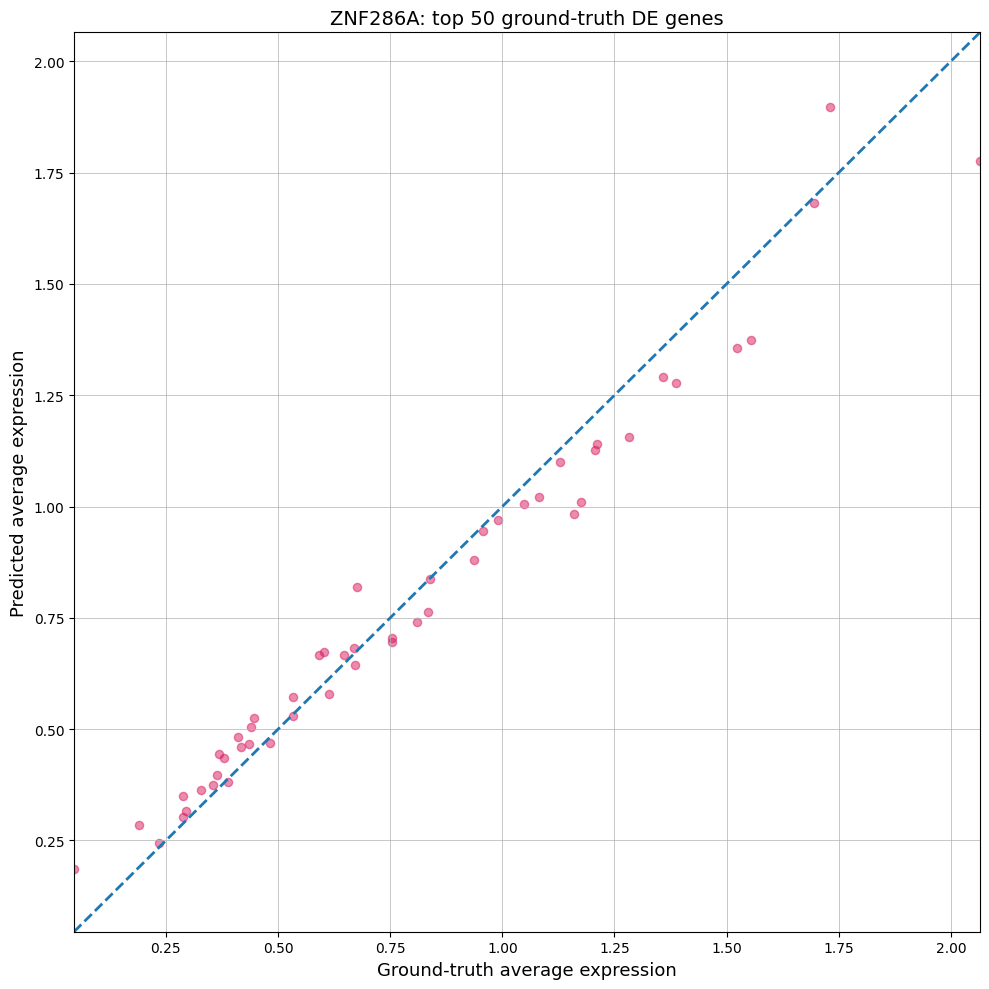

In [63]:
df_top = plot_top_de_gene_expression(
    gt_adata=real_adata,
    pred_adata=pred_adata,
    perturbation="ZNF286A",
    K=50,
    pert_key="target_gene",
    control_label="non-targeting",
)

In [87]:
from scipy import sparse
from matplotlib import pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess


def plot_top_de_gene_expression(
    gt_adata,
    pred_adata,
    perturbation,
    K=100,
    pert_key="target_gene",
    control_label="control",
    gene_names=None,
    point_size=35,
    figsize=(10, 10),
):
    """
    For one perturbation, plot average ground-truth expression vs average
    predicted expression for the top K ground-truth DE genes.

    Top DE genes are selected by absolute mean expression shift:
        |mean(gt perturbed) - mean(gt control)|
    """

    # align genes
    common_genes = gt_adata.var_names.intersection(pred_adata.var_names)
    gt = gt_adata[:, common_genes]
    pred = pred_adata[:, common_genes]

    genes = np.array(common_genes)

    def mean_expr(adata, mask):
        X = adata[mask].X
        if sparse.issparse(X):
            return np.asarray(X.mean(axis=0)).ravel()
        return np.asarray(X).mean(axis=0)

    gt_labels = gt.obs[pert_key].astype(str)
    pred_labels = pred.obs[pert_key].astype(str)

    gt_pert_mask = gt_labels == perturbation
    gt_ctrl_mask = gt_labels == control_label
    pred_pert_mask = pred_labels == perturbation

    if gt_pert_mask.sum() == 0:
        raise ValueError(f"No ground-truth cells found for perturbation '{perturbation}'")
    if pred_pert_mask.sum() == 0:
        raise ValueError(f"No predicted cells found for perturbation '{perturbation}'")
    if gt_ctrl_mask.sum() == 0:
        raise ValueError(f"No control cells found with label '{control_label}'")

    gt_pert_mean = mean_expr(gt, gt_pert_mask)
    gt_ctrl_mean = mean_expr(gt, gt_ctrl_mask)
    pred_pert_mean = mean_expr(pred, pred_pert_mask)

    # top K ground-truth DE genes
    de_score = np.abs(gt_pert_mean - gt_ctrl_mean)
    top_idx = np.argsort(de_score)[::-1][:K]

    x = gt_pert_mean[top_idx]
    y = pred_pert_mean[top_idx]
    top_genes = genes[top_idx]

    def local_std_band(x, y, window_frac=0.25):
        order = np.argsort(x)
        xs = x[order]
        residuals = (y - x)[order]
        window = max(5, int(len(xs) * window_frac))
        local_std = pd.Series(residuals).rolling(
            window=window,
            center=True,
            min_periods=max(3, window // 3),
        ).std()
        local_std = local_std.bfill().ffill().to_numpy()
        return xs, local_std
    # def local_std_band(x, y, frac=0.4):
    #     order = np.argsort(x)
    #     xs = x[order]
    #     residuals = (y - x)[order]
    #     var = lowess(
    #         residuals**2,
    #         xs,
    #         frac=frac,
    #         return_sorted=False,
    #     )
    #     sigma = np.sqrt(np.maximum(var, 0))
    #     return xs, sigma

    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(x, y, s=point_size, alpha=0.5, color='#D81B60')

    # identity line + local residual variance band
    lim_min = min(x.min(), y.min())
    lim_max = max(x.max(), y.max())

    xx_band, local_sigma = local_std_band(x, y, window_frac=0.25)

    ax.fill_between(
        xx_band,
        xx_band - local_sigma,
        xx_band + local_sigma,
        color="royalblue",
        alpha=0.15,
        linewidth=0,
        label=r"local $\pm 1\sigma$",
    )

    ax.plot(
        [lim_min, lim_max],
        [lim_min, lim_max],
        linewidth=2,
        linestyle="--",
        color="royalblue",
        label="y = x",
    )

    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)

    ax.set_xlabel("Ground-truth average expression", fontsize=13)
    ax.set_ylabel("Predicted average expression", fontsize=13)
    ax.set_title(f"{perturbation}: top {K} ground-truth DE genes", fontsize=14)

    ax.grid(True, linewidth=0.5)

    plt.tight_layout()
    plt.show()

    return pd.DataFrame({
        "gene": top_genes,
        "gt_mean": x,
        "pred_mean": y,
        "gt_control_mean": gt_ctrl_mean[top_idx],
        "abs_gt_de": de_score[top_idx],
    })